Processing row 1/6: Pure...
Processing row 2/6: Vrad only...
Processing row 3/6: PA twist (Same Sign)...
Processing row 4/6: PA twist (Diff Sign)...
Processing row 5/6: Suppressing...
Processing row 6/6: Enhancing...
Saving output to Comparison_Grid_6x4.pdf...
Done.


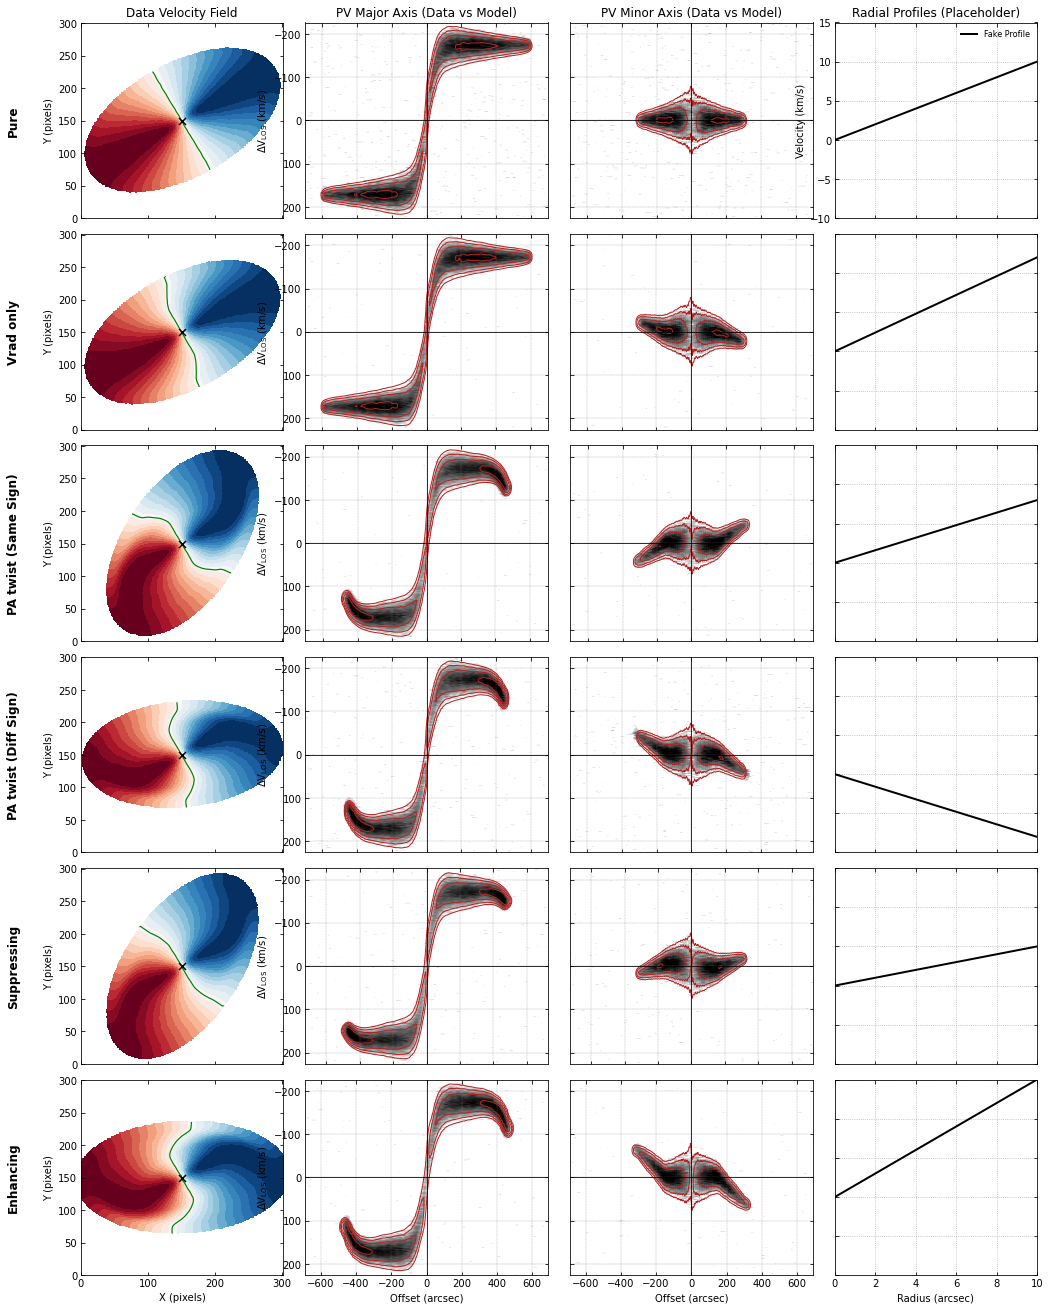

In [ ]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import ColorbarBase
from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from copy import copy
import warnings

# 忽略一些FITS头文件警告和除零警告，保持输出整洁
warnings.filterwarnings("ignore")

# --- Plotting Style Setup (from your scripts) ---
mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)
mpl.rcParams['contour.negative_linestyle'] = 'solid'
plt.rc('font', family='sans-serif', serif='Helvetica', size=10)
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'}
plt.rcParams.update(params)

# =================Configuration=================
# 基础路径前缀，根据你的服务器环境调整。
# 你的代码示例中使用了 '/net/dataserver3/'，所以我假设这是根目录。
base_path = '/net/'

# 定义6个模型的名称和相对路径
models_config = [
    ("Pure", "dataserver3/data/users/linn/para_Barolo/test_more_model/ring_v200_R50_PAfixed_VR0_INC60/second_step_check_sinw/"),
    ("Vrad only", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAfixed_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA twist (Same Sign)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VR0_INC60/second_step_check_sinw/"),
    ("PA twist (Diff Sign)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VR0_INC60/second_step_check_sinw/SNR10Res10mod_maps_azim.pdf"), # 注意：这里你给的路径结尾是pdf，我假设需要去掉文件名回到目录
    ("Suppressing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("Enhancing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/")
]

# 清理路径（处理第4个路径结尾是pdf的情况）
cleaned_models = []
for title, path in models_config:
    if path.endswith('.pdf'):
        path = os.path.dirname(path) + '/'
    cleaned_models.append((title, os.path.join(base_path, path)))
models_config = cleaned_models

# 通用参数
gname = 'SNR10Res10mod'
xmin, xmax = 250, 550
ymin, ymax = 250, 550
zmin, zmax = 10, 190 # for PV slicing
twostage = 1
cmap_vel = plt.get_cmap('RdBu_r', 25) # Velocity cmap

# =================Helper Functions=================

def get_vsys_and_center(outfolder):
    """从 rings 文件中读取 vsys 和中心点"""
    try:
        ring_file = outfolder + ('rings_final2.txt' if twostage else 'rings_final1.txt')
        # usecols=(9,10,11) corresponding to xpos, ypos, vsys based on your script
        xpos, ypos, vsys_arr = np.genfromtxt(ring_file, usecols=(9, 10, 11), unpack=True)
        xcen_m, ycen_m, vsys_m = np.nanmean((xpos, ypos, vsys_arr), axis=1)
        return vsys_m, xcen_m - xmin, ycen_m - ymin
    except Exception as e:
        print(f"Warning: Could not read rings file in {outfolder}. Using defaults. Error: {e}")
        return 0, (xmax-xmin)/2, (ymax-ymin)/2

def plot_mom1(ax, outfolder, vsys_m, xcen, ycen, is_bottom_row):
    """绘制 Velocity Field (Moment 1) Data"""
    f1 = fits.open(outfolder + '/maps/' + gname + '_azim_1mom.fits')
    mom1 = f1[0].data[ymin:ymax+1, xmin:xmax+1]
    f1.close()
    
    # Data to plot: V_los - V_sys
    data_to_plot = mom1 - vsys_m
    
    # Calculate Extent
    # 假设像素比例是1，如果需要精确的arcsec，需要读header的CDELT
    # 这里沿用你脚本里的简单处理 ext = [0,xmax-xmin,0, ymax-ymin]
    ext = [0, xmax - xmin, 0, ymax - ymin]

    # Normalize colors centered on 0
    interval = PercentileInterval(99.5)
    vmin, vmax = interval.get_limits(data_to_plot)
    vabs = max(abs(vmin), abs(vmax))
    norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
    
    cmap = copy(cmap_vel)
    cmap.set_bad('w', 1.)
    
    im = ax.imshow(data_to_plot, origin='lower', cmap=cmap, norm=norm, aspect='auto', extent=ext, interpolation='nearest')
    ax.plot(xcen, ycen, 'x', color='#000000', markersize=7, mew=1.5)
    #-----------添加majorandminor-----------！！！
    # 1. Isovelocity Contour (Green) - Data V=0

    maskmap = np.copy(mom1)
    maskmap[mom1==mom1] = 1
    ax.contour(data_to_plot*maskmap, levels=[0], colors='green', origin='lower', extent=ext, linewidths=1.2)
    #---------------------------------！！！
    
    ax.set_ylabel('Y (pixels)')
    if is_bottom_row:
        ax.set_xlabel('X (pixels)')
    else:
        ax.tick_params(labelbottom=False)
    pad = 50

    ax.set_xlim(-pad, (xmax - xmin) + pad)
    ax.set_ylim(-pad, (ymax - ymin) + pad)
        
    return im, norm # Return useful info for colorbar if needed

def plot_pv(ax, outfolder, pv_type, vsys_m, is_bottom_row, is_left_col):
    """
    核心PV绘图函数。
    复用了你提供的脚本中计算WCS、归一化和绘制等高线的逻辑。
    pv_type: 'major' or 'minor'
    """
    suffix_data = '_pv_a.fits' if pv_type == 'major' else '_pv_b.fits'
    suffix_mod = '_azim.fits' # 假设使用 azim 模型进行对比

    # 1. Load Data FITS and Headers
    f_data = fits.open(outfolder + 'pvs/' + gname + suffix_data)
    head = f_data[0].header
    
    # 2. WCS Calculation (Crucial part from your script)
    crpix = head['CRPIX1']
    cdelt = head['CDELT1']
    crval = head['CRVAL1']
    # Need total width to define xminpv/xmaxpv correctly relative to center
    naxis1 = head['NAXIS1'] 
    
    # Define cropping window (±150 pixels from center, as in your script)
    xminpv = max(0, np.floor(crpix - 1 - 150))
    xmaxpv = min(naxis1 - 1, np.ceil(crpix - 1 + 150))

    # Convert to Arcsec (Spatial X-axis)
    xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
    xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600
    
    # Velocity Y-axis (hardcoded based on your script, could be dynamic)
    zmin_wcs, zmax_wcs = 262.75, -189.75 # 你的脚本里是硬编码的
    
    ext = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]

    # 3. Crop Data based on Z and X limits
    data_crop = f_data[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
    f_data.close()

    # 4. Find Model file (searching for _azim.fits)
    model_file = None
    pv_mod_dir = outfolder + 'pvs/'
    search_str = f"pv_{'a' if pv_type=='major' else 'b'}_azim.fits"
    for file in os.listdir(pv_mod_dir):
        if search_str in file:
            model_file = os.path.join(pv_mod_dir, file)
            break
    
    if model_file:
        f_mod = fits.open(model_file)
        mod_crop = f_mod[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
        f_mod.close()
    else:
        mod_crop = np.zeros_like(data_crop)
        print(f"Warning: Model PV file not found for {pv_type} in {outfolder}")

    # 5. Normalization and Contours setup
    cont = 0.000598286 # From your script
    v = np.array([1, 2, 4, 8, 16, 32, 64]) * cont
    v_neg = [-cont]
    interval = PercentileInterval(99.5)
    vmax_norm = interval.get_limits(data_crop)[1]
    # Avoid error if data is empty or all nan
    if np.isnan(vmax_norm) or vmax_norm <= cont: vmax_norm = cont * 10 
    norm = ImageNormalize(vmin=cont, vmax=vmax_norm, stretch=PowerStretch(0.5))

    # 6. Plotting
    # Data Image (Greyscale)
    ax.imshow(data_crop, origin='lower', cmap=mpl.cm.Greys, norm=norm, extent=ext, aspect='auto')
    # Data Contours (Blue)
    #ax.contour(data_crop, v, origin='lower', linewidths=0.7, colors='#00008B', extent=ext)
    ax.contour(data_crop, v_neg, origin='lower', linewidths=0.1, colors='gray', extent=ext)
    # Model Contours (Red)
    if model_file:
        ax.contour(mod_crop, v, origin='lower', linewidths=1, colors='#B22222', extent=ext)
        
    # Aesthetics
    ax.axhline(y=0, color='black', lw=0.8)
    ax.axvline(x=0, color='black', lw=0.8)
    ax.grid(color='gray', linestyle='--', linewidth=0.3)

    if is_left_col:
        ax.set_ylabel('$\Delta V_{LOS}$ (km/s)')
    else:
        ax.tick_params(labelleft=False)
        
    if is_bottom_row:
        ax.set_xlabel('Offset (arcsec)')
    else:
        ax.tick_params(labelbottom=False)

def plot_dummy_profile(ax, row_idx, is_bottom_row):
    """第四列的占位Profile图"""
    x = np.linspace(0, 10, 50)
    # 模拟不同斜率的线
    slopes = [1, 1.2, 0.8, -0.8, 0.5, 1.5]
    y = slopes[row_idx] * x
    
    ax.plot(x, y, 'k-', lw=2, label='Fake Profile')
    ax.set_xlim(0, 10)
    ax.set_ylim(-10, 15)
    ax.grid(True, ls=':')
    
    if is_bottom_row:
        ax.set_xlabel('Radius (arcsec)')
    else:
        ax.tick_params(labelbottom=False)
    
    # 只在第一行显示 ylabel 和 legend，避免杂乱
    if row_idx == 0:
        ax.set_ylabel('Velocity (km/s)')
        ax.legend(fontsize=8, frameon=False)
    else:
        ax.tick_params(labelleft=False)

# =================Main Script=================

# 设置画布大小 (高一点以容纳6行)
fig = plt.figure(figsize=(16, 20))

# 定义网格: 6行, 4列
# width_ratios 控制列宽比例，PV图通常比地图宽一点
gs = gridspec.GridSpec(6, 4, width_ratios=[1, 1.2, 1.2, 1], wspace=0.1, hspace=0.08)

nrows = 6
ncols = 4

# 循环处理每一行（每一个模型）
for i in range(nrows):
    row_title, model_path = models_config[i]
    is_bottom = (i == nrows - 1)
    
    print(f"Processing row {i+1}/{nrows}: {row_title}...")

    # 获取该模型的全局参数 (vsys, center)
    vsys_m, xcen, ycen = get_vsys_and_center(model_path)
    
    # --- Column 1: Velocity Field (Moment 1) ---
    ax0 = fig.add_subplot(gs[i, 0])
    try:
        im_vel, norm_vel = plot_mom1(ax0, model_path, vsys_m, xcen, ycen, is_bottom)
        # 在最左侧添加模型标题
        ax0.text(-0.3, 0.5, row_title, transform=ax0.transAxes, 
                 va='center', ha='right', fontsize=12, fontweight='bold', rotation=90)
        if i == 0: ax0.set_title("Data Velocity Field", fontsize=12)
            
    except FileNotFoundError as e:
        ax0.text(0.5, 0.5, f"File Not Found:\n{e.filename}", ha='center', va='center', fontsize=8, color='red')
        print(f"Error in row {i}, col 0: {e}")

    # --- Column 2: PV Major Axis ---
    ax1 = fig.add_subplot(gs[i, 1])
    try:
        # PV Major: is_left_col=True 因为它是PV图的第一列，需要Y轴标签
        plot_pv(ax1, model_path, 'major', vsys_m, is_bottom, is_left_col=True)
        if i == 0: ax1.set_title("PV Major Axis (Data vs Model)", fontsize=12)
    except Exception as e:
        ax1.text(0.5, 0.5, "PV Major Error", ha='center')
        print(f"Error in row {i}, col 1: {e}")

    # --- Column 3: PV Minor Axis ---
    ax2 = fig.add_subplot(gs[i, 2])
    try:
        # PV Minor: is_left_col=False，共享 Major 的Y轴标签
        plot_pv(ax2, model_path, 'minor', vsys_m, is_bottom, is_left_col=False)
        if i == 0: ax2.set_title("PV Minor Axis (Data vs Model)", fontsize=12)
    except Exception as e:
        ax2.text(0.5, 0.5, "PV Minor Error", ha='center')
        print(f"Error in row {i}, col 2: {e}")

    # --- Column 4: Profile Placeholder ---
    ax3 = fig.add_subplot(gs[i, 3])
    plot_dummy_profile(ax3, i, is_bottom)
    if i == 0: ax3.set_title("Radial Profiles (Placeholder)", fontsize=12)

# --- 添加 Colorbar ---
# 为第一列的 Velocity Field 添加一个共享的 Colorbar
# 获取最后一行的 axis 对象位置
pos0 = ax0.get_position()
# 在最底部添加一个新的 axis 用于 colorbar
# cax = fig.add_axes([pos0.x0, pos0.y0 - 0.04, pos0.width, 0.01])
# # 使用最后一次循环的 cmap 和 norm (假设所有图的 scale 差不多，或者你可以固定一个 norm)
# # 这里为了简单，使用了最后一张图的norm。更好的方式是预先计算所有图的全局最大最小值。
# cb = ColorbarBase(cax, orientation='horizontal', cmap=cmap_vel, norm=norm_vel)
# cb.set_label(r'$\Delta V_{LOS}$ (km/s)', fontsize=10)
# cb.ax.tick_params(labelsize=9)

# 保存图片
output_file = 'Comparison_Grid_6x4.pdf'
print(f"Saving output to {output_file}...")
# 调整边距以适应左侧的标题和底部的 colorbar
plt.subplots_adjust(left=0.12, bottom=0.08, right=0.95, top=0.95)
fig.savefig(output_file, dpi=150)
print("Done.")
# plt.show() # 如果需要在屏幕上显示，取消注释

Plotting Row 1: Pure...
Plotting Row 2: Vrad...
Plotting Row 3: PA Same...
Plotting Row 4: Suppressing...
Plotting Row 5: PA Diff...
Plotting Row 6: Enhancing...
Finished. Saved to Final_Kinematic_Comparison_6x4.pdf


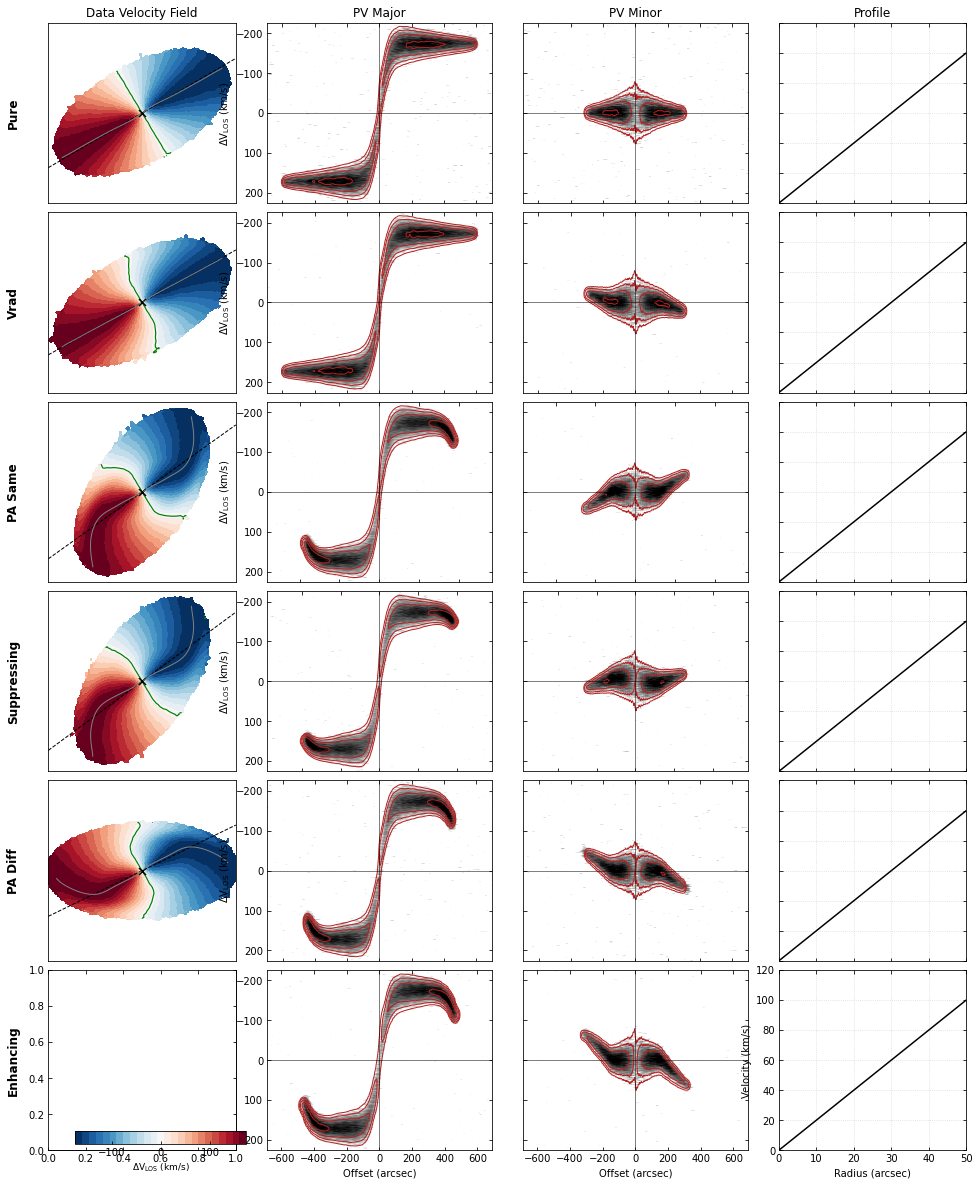

In [ ]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import ColorbarBase
from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from copy import copy
import warnings
import glob

# ================= 基础设置 =================
warnings.filterwarnings("ignore")

mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)
mpl.rcParams['contour.negative_linestyle'] = 'solid'
plt.rc('font', family='sans-serif', serif='Helvetica', size=10)
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'}
plt.rcParams.update(params)

# ★★★ 请根据服务器修改此处 ★★★
base_path = '/net/'  
# base_path = '/' # 如果路径已经是绝对路径，使用这个

# ================= 模型路径配置 =================
# 原始列表 (Title, Relative Path)
models_raw = [
    ("Pure", "dataserver3/data/users/linn/para_Barolo/test_more_model/ring_v200_R50_PAfixed_VR0_INC60/second_step_check_sinw/"),
    ("Vrad", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAfixed_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA Same", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VR0_INC60/second_step_check_sinw/"),
    ("PA Diff", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VR0_INC60/second_step_check_sinw/SNR10Res10mod_maps_azim.pdf"), 
    ("Suppressing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("Enhancing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/")
]

# 1. 清洗路径 (处理 pdf 结尾, 拼接 base_path)
models_clean = []
for title, path in models_raw:
    if path.endswith('.pdf'):
        path = os.path.dirname(path) + '/'
    if not path.endswith('/'):
        path += '/'
    # 拼接完整路径
    full_path = os.path.join(base_path, path)
    models_clean.append((title, full_path))

# 2. 调整顺序：交换 "PA Diff"(idx 3) 和 "Suppressing"(idx 4)
# 目标顺序: Pure(0), Vrad(1), PA Same(2), Suppressing(4), PA Diff(3), Enhancing(5)
plot_order = [0, 1, 2, 4, 3, 5]
models_ordered = [models_clean[i] for i in plot_order]

# ================= 全局参数 =================
gname = 'SNR10Res10mod'
xmin, xmax = 250, 550
ymin, ymax = 250, 550
zmin, zmax = 10, 190
twostage = 1 
cmap_vel = plt.get_cmap('RdBu_r', 25)

# ================= 辅助函数定义 =================

def get_rings_data(outfolder):
    """读取 rings_final2.txt 获取几何参数和数组"""
    fname = 'rings_final2.txt' if twostage else 'rings_final1.txt'
    path = os.path.join(outfolder, fname)
    try:
        # Col 1:rad, 4:inc, 5:pa, 9:xpos, 10:ypos, 11:vsys
        data = np.genfromtxt(path, usecols=(1, 4, 5, 9, 10, 11), unpack=True)
        rad, inc, pa, xpos, ypos, vsys = data
        
        # 计算均值
        return {
            'rad': rad, 'inc': inc, 'pa': pa, 
            'vsys_m': np.nanmean(vsys),
            'xcen_m': np.nanmean(xpos),
            'ycen_m': np.nanmean(ypos),
            'pa_m': np.nanmean(pa),
            'inc_m': np.nanmean(inc)
        }
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return None

def plot_mom1(ax, outfolder, p_data, is_bottom_row):
    """
    第1列：Data Velocity Field
    包含：Global Major(黑虚), Warped Axis(灰实/点), Green Contour(V=0)
    """
    if p_data is None: return None, None
    
    # 解包数据
    vsys_m = p_data['vsys_m']
    xcen = p_data['xcen_m'] - xmin
    ycen = p_data['ycen_m'] - ymin
    rad = p_data['rad']
    pa = p_data['pa']
    pa_m = p_data['pa_m']
    
    # 读取 Data Map
    fpath = os.path.join(outfolder, 'maps', gname + '_1mom.fits')
    if not os.path.exists(fpath):
        ax.text(0.5, 0.5, "Data Map Missing", ha='center')
        return None, None

    f1 = fits.open(fpath)
    mom1 = f1[0].data[ymin:ymax+1, xmin:xmax+1]
    f1.close()
    
    data_to_plot = mom1 - vsys_m
    ext = [0, xmax - xmin, 0, ymax - ymin]

    # Normalize
    interval = PercentileInterval(99.5)
    vmin, vmax = interval.get_limits(data_to_plot)
    vabs = max(abs(vmin), abs(vmax))
    norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
    
    cmap = copy(cmap_vel)
    cmap.set_bad('w', 1.)
    
    # 绘图
    im = ax.imshow(data_to_plot, origin='lower', cmap=cmap, norm=norm, aspect='auto', extent=ext, interpolation='nearest')
    ax.plot(xcen, ycen, 'x', color='#000000', markersize=7, mew=1.5)

    # --- 绘制辅助线 (基于您的代码) ---
    x_grid = np.arange(0, xmax - xmin, 0.1)
    
    # 1. Global Major Axis (Black Dashed)
    y_maj = np.tan(np.radians(pa_m - 90)) * (x_grid - xcen) + ycen
    ax.plot(x_grid, y_maj, '--', color='k', linewidth=1)

    # 2. Global Minor Axis (Gray Solid, Optional but usually good for ref)
    # y_min = np.tan(np.radians(pa_m)) * (x_grid - xcen) + ycen
    # ax.plot(x_grid, y_min, '-', color='gray', linewidth=1, alpha=0.5)

    # 3. Warped Axis (Grey Points/Lines) - 您的逻辑
    rad_pix = rad / 4.0  # 假设 pixel scale 关系
    nr = len(rad_pix) if isinstance(rad_pix, np.ndarray) else 1
    
    if nr < 10:
        x_pix = rad_pix * np.cos(np.radians(pa_m - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_m - 90))
        ax.scatter(x_pix + xcen, y_pix + ycen, c='grey', s=12)
        ax.scatter(xcen - x_pix, ycen - y_pix, c='grey', s=12)
    
    if nr > 5 and not np.all(np.diff(pa) == 0):
        x_pix = rad_pix * np.cos(np.radians(pa - 90))
        y_pix = rad_pix * np.sin(np.radians(pa - 90))
        ax.plot(xcen - x_pix, ycen - y_pix, '-', color='grey', lw=1)
        ax.plot(x_pix + xcen, y_pix + ycen, '-', color='grey', lw=1)

    # 4. Isovelocity Contour (Green, Level=0)
    maskmap = np.copy(mom1)
    maskmap[mom1==mom1] = 1
    ax.contour(data_to_plot * maskmap, levels=[0], colors='green', origin='lower', extent=ext, linewidths=1.2)
    
    # 坐标轴清理
    ax.set_xlim(0, xmax - xmin)
    ax.set_ylim(0, ymax - ymin)
    ax.set_xticks([])
    ax.set_yticks([])
    
    if is_bottom_row:
        # 即使是最后一行也不要 Label (根据您的要求：不需要横纵坐标)
        pass 
        
    return im, norm

def plot_pv_hybrid(ax, outfolder, pv_type, p_data, is_left_col, is_bottom):
    """
    第2、3列：PV Diagrams
    背景：Data (Grey)
    Contour：Model (Red only)
    """
    vsys_m = p_data['vsys_m']
    suffix_data = '_pv_a.fits' if pv_type == 'major' else '_pv_b.fits'
    
    # 读取 Data PV
    f_data_path = os.path.join(outfolder, 'pvs', gname + suffix_data)
    if not os.path.exists(f_data_path): 
        ax.text(0.5, 0.5, "Data PV Missing", ha='center')
        return

    f = fits.open(f_data_path)
    head = f[0].header
    
    # WCS 计算
    crpix = head['CRPIX1']
    cdelt = head['CDELT1']
    crval = head['CRVAL1']
    naxis1 = head['NAXIS1']
    xminpv = max(0, np.floor(crpix - 1 - 150))
    xmaxpv = min(naxis1 - 1, np.ceil(crpix - 1 + 150))
    xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
    xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600
    zmin_wcs, zmax_wcs = 262.75, -189.75 # Hardcoded
    
    ext = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]
    data_crop = f[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
    f.close()
    
    # Normalize Data (Greyscale)
    cont = 0.000598286
    interval = PercentileInterval(99.5)
    vmax_norm = interval.get_limits(data_crop)[1]
    if np.isnan(vmax_norm): vmax_norm = cont*10
    norm = ImageNormalize(vmin=cont, vmax=vmax_norm, stretch=PowerStretch(0.5))
    
    ax.imshow(data_crop, origin='lower', cmap=mpl.cm.Greys, norm=norm, extent=ext, aspect='auto')
    
    # 读取并叠加 Model PV (Red Contours)
    suffix_mod = f'pv_{"a" if pv_type=="major" else "b"}_azim.fits'
    # 查找 azim 或 local
    mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))
    if not mod_files:
        suffix_mod = f'pv_{"a" if pv_type=="major" else "b"}_local.fits'
        mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))

    if mod_files:
        f_mod = fits.open(mod_files[0])
        mod_crop = f_mod[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
        v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont
        # 只画红色
        ax.contour(mod_crop, v_levels, origin='lower', linewidths=1, colors='#B22222', extent=ext)
        f_mod.close()
    
    # 辅助线
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    
    # Labels
    if is_left_col:
        ax.set_ylabel(r'$\Delta V_{LOS}$ (km/s)')
    else:
        ax.set_yticklabels([])
        
    if is_bottom:
        ax.set_xlabel('Offset (arcsec)')
    else:
        ax.set_xticklabels([])

def plot_profile(ax, p_data, is_bottom):
    """
    第4列：Profile
    请在此处自定义您的绘图逻辑，例如 y = nx
    """
    # 示例：画 y = 2x 的虚线
    x = np.linspace(0, 50, 100)
    y = 2.0 * x 
    
    ax.plot(x, y, 'k-', lw=1.5, label='y=nx')
    
    # 简单的格式设置
    ax.set_ylim(0, 120)
    ax.set_xlim(0, 50)
    ax.grid(True, ls=':', alpha=0.5)
    
    if is_bottom:
        ax.set_xlabel('Radius (arcsec)')
        ax.set_ylabel('Velocity (km/s)') # 或者其他单位
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])

# ================= 主程序执行 =================

fig = plt.figure(figsize=(15, 18))
# 4列: Map | PV Major | PV Minor | Profile
gs = gridspec.GridSpec(6, 4, width_ratios=[1, 1.2, 1.2, 1], wspace=0.15, hspace=0.05)
rows = 6

global_im, global_norm = None, None

for i in range(rows):
    title, path = models_ordered[i]
    is_bottom = (i == rows - 1)
    print(f"Plotting Row {i+1}: {title}...")
    
    # 获取几何数据
    p_data = get_rings_data(path)
    if p_data is None: continue
    
    # --- 1. Data Velocity Field ---
    ax0 = fig.add_subplot(gs[i, 0])
    im, norm = plot_mom1(ax0, path, p_data, is_bottom)
    if i == 0: 
        global_im, global_norm = im, norm
        ax0.set_title("Data Velocity Field")
    
    # 行标题 (左侧)
    ax0.text(-0.15, 0.5, title, transform=ax0.transAxes, 
             va='center', ha='right', fontsize=12, fontweight='bold', rotation=90)

    # --- 2. PV Major (Data=Grey, Model=Red) ---
    ax1 = fig.add_subplot(gs[i, 1])
    plot_pv_hybrid(ax1, path, 'major', p_data, is_left_col=True, is_bottom=is_bottom)
    if i == 0: ax1.set_title("PV Major")

    # --- 3. PV Minor (Data=Grey, Model=Red) ---
    ax2 = fig.add_subplot(gs[i, 2])
    plot_pv_hybrid(ax2, path, 'minor', p_data, is_left_col=False, is_bottom=is_bottom)
    if i == 0: ax2.set_title("PV Minor")
    
    # --- 4. Profile (Placeholder) ---
    ax3 = fig.add_subplot(gs[i, 3])
    plot_profile(ax3, p_data, is_bottom)
    if i == 0: ax3.set_title("Profile")

# --- 添加 Colorbar (Velocity Field) ---
if global_im:
    # 获取最后一行的位置
    pos_last = fig.add_subplot(gs[rows-1, 0]).get_position()
    # 在下方添加 colorbar
    cax = fig.add_axes([pos_last.x0, pos_last.y0 - 0.04, pos_last.width, 0.01])
    cb = ColorbarBase(cax, orientation='horizontal', cmap=cmap_vel, norm=global_norm)
    cb.set_label(r'$\Delta V_{LOS}$ (km/s)', fontsize=9)

# 保存文件
output_file = 'Final_Kinematic_Comparison_6x4.pdf'
plt.subplots_adjust(left=0.1, bottom=0.08, right=0.95, top=0.95)
fig.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"Finished. Saved to {output_file}")

In [15]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import ColorbarBase
from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from copy import copy
import warnings
import glob

# ================= 基础设置 =================
warnings.filterwarnings("ignore")

mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)
mpl.rcParams['contour.negative_linestyle'] = 'solid'
plt.rc('font', family='sans-serif', serif='Helvetica', size=10)
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'}
plt.rcParams.update(params)

# ★★★ 请根据服务器修改此处 ★★★
base_path = '/net/'  

# ================= 模型路径配置 =================
models_raw = [
    ("Pure rotation", "dataserver3/data/users/linn/para_Barolo/test_more_model/ring_v200_R50_PAfixed_VR0_INC60/second_step_check_sinw/"),
    ("$V_{\rm rad}$", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAfixed_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA (+)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VR0_INC60/second_step_check_sinw/"),
    ("Suppressing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA (-)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VR0_INC60/second_step_check_sinw/SNR10Res10mod_maps_azim.pdf"), 
    ("Enhancing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/")
]

# 1. 清洗路径 (处理 pdf 结尾, 拼接 base_path)
models_clean = []
for title, path in models_raw:
    if path.endswith('.pdf'):
        path = os.path.dirname(path) + '/'
    if not path.endswith('/'):
        path += '/'
    full_path = os.path.join(base_path, path)
    models_clean.append((title, full_path))

# 保持顺序
models_ordered = models_clean

# ================= 全局参数 =================
gname = 'SNR10Res10mod'
xmin, xmax = 250, 550
ymin, ymax = 250, 550
zmin, zmax = 10, 190
twostage = 1 
cmap_vel = plt.get_cmap('RdBu_r', 25)

# ================= 辅助函数定义 =================

def get_rings_data(outfolder):
    """读取 rings_final2.txt 获取详细几何参数(PA array, Rad array等)用于画线"""
    fname = 'rings_final2.txt' if twostage else 'rings_final1.txt'
    path = os.path.join(outfolder, fname)
    try:
        # 读取列: 1:Rad, 4:Inc, 5:PA, 9:Xpos, 10:Ypos, 11:Vsys
        data = np.genfromtxt(path, usecols=(1, 4, 5, 9, 10, 11), unpack=True)
        rad, inc, pa, xpos, ypos, vsys = data
        
        return {
            'rad': rad, 'pa': pa, 
            'vsys_m': np.nanmean(vsys),
            'xcen_m': np.nanmean(xpos),
            'ycen_m': np.nanmean(ypos),
            'pa_m': np.nanmean(pa),
            'inc_m': np.nanmean(inc)
        }
    except Exception as e:
        print(f"Error reading rings from {path}: {e}")
        return None

def plot_mom1(ax, outfolder, p_data, is_bottom_row):
    """
    第1列：Data Velocity Field
    包含：Global Major(黑虚), Warped Axis(灰实/点), Green Contour(V=0)
    """
    if p_data is None: 
        ax.text(0.5,0.5, "No Rings Data", ha='center')
        return None, None
    
    # 解包数据
    vsys_m = p_data['vsys_m']
    xcen = p_data['xcen_m'] - xmin
    ycen = p_data['ycen_m'] - ymin
    rad = p_data['rad']
    pa = p_data['pa']
    pa_m = p_data['pa_m']
    
    # 读取 Data Map (注意：这里读取的是 DATA 的 mom1)
    fpath = os.path.join(outfolder, 'maps', gname + '_azim_1mom.fits')
    f1 = fits.open(fpath)
    mom1 = f1[0].data[-10+ymin:ymax+10, -10+xmin:xmax+10]
    f1.close()
    
    data_to_plot = mom1 - vsys_m
    ext = [0, xmax - xmin, 0, ymax - ymin]

    # Normalize
    interval = PercentileInterval(99.5)
    vmin, vmax = interval.get_limits(data_to_plot)
    vabs = max(abs(vmin), abs(vmax))
    norm = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)
    
    cmap = copy(cmap_vel)
    cmap.set_bad('w', 1.)
    
    # 绘图
    im = ax.imshow(data_to_plot, origin='lower', cmap=cmap, norm=norm, aspect='equal', extent=ext, interpolation='nearest')
    ax.plot(xcen, ycen, 'x', color='#000000', markersize=7, mew=1.5)

    # --- 绘制辅助线 (基于您的代码逻辑) ---
    x_grid = np.arange(0, xmax - xmin, 0.1)
    
    # 1. Global Major Axis (Black Dashed)
    y_maj = np.tan(np.radians(pa_m - 90)) * (x_grid - xcen) + ycen
    ax.plot(x_grid, y_maj, '--', color='k', linewidth=1, alpha=0.8)

    # 2. Global Minor Axis (Grey Solid)
    y_min = np.tan(np.radians(pa_m)) * (x_grid - xcen) + ycen
    ax.plot(x_grid, y_min, '--', color='k', linewidth=1, alpha=0.8)
    ax.set_xlim(-10, xmax - xmin+10)
    ax.set_ylim(-10, ymax - ymin+10)
    
    # 去除 ticks 和 labels
    ax.set_xticks([])
    ax.set_yticks([])
    
    if is_bottom_row:
        pass 
        
    

    # 3. Warped Axis / Locus (复用您的代码)
    rad_pix = rad / 4.0  # 您的缩放比例
    try: nr = len(rad_pix)
    except: nr = 1

    if np.std(pa) < 1e-6:
        pa_use = np.full_like(pa, pa_m)
    else:
        pa_use = pa
    
    # 绘制弯曲的 Major Axis
    if nr < 10:
        x_pix = rad_pix * np.cos(np.radians(pa_m - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_m - 90))
        ax.scatter(x_pix + xcen, y_pix + ycen, c='grey', s=12)
        ax.scatter(xcen - x_pix, ycen - y_pix, c='grey', s=12)
    
    if nr > 5 and not np.all(np.diff(pa) == 0):
        x_pix = rad_pix * np.cos(np.radians(pa_use - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_use - 90))
        ax.plot(xcen - x_pix, ycen - y_pix, '-', color='grey', lw=1)
        ax.plot(x_pix + xcen, y_pix + ycen, '-', color='grey', lw=1)
    
    # 4. Isovelocity Contour (Green, Level=0)
    maskmap = np.copy(mom1)
    maskmap[mom1==mom1] = 1
    ax.contour(data_to_plot * maskmap, levels=[0], colors='green', origin='lower', extent=ext, linewidths=1.2)
    
    # 坐标轴清理
    # 限制显示范围为 Data 切片大小，防止线条画出界
    
    if not os.path.exists(fpath):
        # 尝试读取 local 或 azim 作为替代，如果 data 不存在
        fpath = os.path.join(outfolder, 'maps', gname + '_azim_1mom.fits')
        if not os.path.exists(fpath):
             ax.text(0.5, 0.5, "Data Map Missing", ha='center')
             return None, None

    return im, norm

def plot_pv_hybrid(ax, outfolder, pv_type, p_data, is_left_col, is_bottom):
    """
    第2、3列：PV Diagrams
    背景：Data (Grey)
    Contour：Model (Red only)
    """
    vsys_m = p_data['vsys_m']
    suffix_data = '_pv_a.fits' if pv_type == 'major' else '_pv_b.fits'
    
    # 读取 Data PV
    f_data_path = os.path.join(outfolder, 'pvs', gname + suffix_data)
    if not os.path.exists(f_data_path): 
        ax.text(0.5, 0.5, "Data PV Missing", ha='center')
        return

    f = fits.open(f_data_path)
    head = f[0].header
    
    # WCS 计算
    crpix = head['CRPIX1']
    cdelt = head['CDELT1']
    crval = head['CRVAL1']
    naxis1 = head['NAXIS1']
    xminpv = max(0, np.floor(crpix - 1 - 150))
    xmaxpv = min(naxis1 - 1, np.ceil(crpix - 1 + 150))
    xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
    xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600
    zmin_wcs, zmax_wcs = 262.75, -189.75 # Hardcoded
    
    ext = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]
    data_crop = f[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
    f.close()
    
    # Normalize Data (Greyscale)
    cont = 0.000598286
    interval = PercentileInterval(99.5)
    vmax_norm = interval.get_limits(data_crop)[1]
    if np.isnan(vmax_norm): vmax_norm = cont*10
    norm = ImageNormalize(vmin=cont, vmax=vmax_norm, stretch=PowerStretch(0.5))
    
    ax.imshow(data_crop, origin='lower', cmap=mpl.cm.Greys, norm=norm, extent=ext, aspect='auto')
    
    # 读取并叠加 Model PV (Red Contours)
    suffix_mod = f'pv_{"a" if pv_type=="major" else "b"}_azim.fits'
    # 查找 azim 或 local
    mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))
    if not mod_files:
        suffix_mod = f'pv_{"a" if pv_type=="major" else "b"}_local.fits'
        mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))

    if mod_files:
        f_mod = fits.open(mod_files[0])
        mod_crop = f_mod[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
        v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont
        # 只画红色
        ax.contour(mod_crop, v_levels, origin='lower', linewidths=1, colors='#B22222', extent=ext)
        f_mod.close()
    
    # 辅助线
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Labels
#     if is_left_col:
#         ax.set_ylabel(r'$\Delta V_{LOS}$ (km/s)')
#     else:
#         ax.set_yticklabels([])
        
#     if is_bottom:
#         ax.set_xlabel('Offset (arcsec)')
#     else:
#         ax.set_xticklabels([])
def get_initial_profile_path(barolo_path):
    """
    将 Barolo 输出路径转换为 Initial Parameter 的 txt 路径
    例如: 
    From: .../para_Barolo/.../ring_v200...INC60/second_step_check_sinw/
    To:   .../para_initial/.../ring_v200...INC60.txt
    """
    # 1. 规范化路径，去除末尾可能存在的 '/'
    p = os.path.normpath(barolo_path)
    
    # 2. 如果路径以 .pdf 结尾，去掉文件名回到目录
    if p.endswith('.pdf'):
        p = os.path.dirname(p)
        
    # 3. 如果末尾是 'second_step_check_sinw'，向上退一级
    if os.path.basename(p) == 'second_step_check_sinw':
        p = os.path.dirname(p)
        
    # 4. 此时 p 应该以 model 文件夹结尾 (e.g., ring_v200...INC60)
    # 替换路径中的 'para_Barolo' 为 'para_initial'
    new_path_base = p.replace('para_Barolo', 'para_initial')
    
    # 5. 加上 .txt 后缀
    txt_path = new_path_base + ".txt"
    
    return txt_path

def plot_real_profile(ax, barolo_path, row_idx, is_bottom_row):
    """
    读取对应的 txt 文件并绘制 PA 和 VRAD 在同一个 Y 轴上
    """
    # 获取转换后的 txt 路径
    txt_path = get_initial_profile_path(barolo_path)
    
    # 检查文件是否存在
    if not os.path.exists(txt_path):
        ax.text(0.5, 0.5, "Txt Not Found", ha='center', fontsize=8)
        print(f"Missing: {txt_path}")
        return

    try:
        # --- 数据读取部分 (保持不变) ---
        try:
            data = np.genfromtxt(txt_path, names=True, encoding=None)
            colnames = [n.upper() for n in data.dtype.names]
            col_rad = next(n for n in colnames if 'RAD' in n)
            col_pa  = next(n for n in colnames if 'P.A' in n or 'PA' in n)
            col_vrad= next(n for n in colnames if 'VRAD' in n)
            
            rad  = data[data.dtype.names[colnames.index(col_rad)]]
            pa   = data[data.dtype.names[colnames.index(col_pa)]]
            vrad = data[data.dtype.names[colnames.index(col_vrad)]]
        except:
            data_arr = np.genfromtxt(txt_path)
            rad  = data_arr[:, 0]
            pa   = data_arr[:, 1]
            vrad = data_arr[:, 2]

        # === 开始绘图 ===
        color_pa = '#2ca02c'   # Green
        color_vr = '#9467bd'   # Purple
        
        # 数据处理
        pa = pa - 120 

        # 1. 绘制 P.A. (实线) -> 使用 ax
        ax.plot(rad, pa, '-', color=color_pa, lw=2, label='$\Delta$ P.A. (deg)')
        
        # 2. 绘制 VRAD (虚线) -> 同样使用 ax (去掉 twinx)
        ax.plot(rad, vrad, '--', color=color_vr, lw=2, label='$\Delta$ Vrad (km/s)')
        
        # 设置 X 轴范围
        ax.set_xlim(left=0, right=np.max(rad)*1.05)
        
        # 设置 Y 轴范围 (自动适应两条线的数据)
        # 获取两组数据的最大最小值来设定范围，或者让 matplotlib 自动处理
        all_y = np.concatenate([pa, vrad])
        if len(all_y) > 0:
            y_min, y_max = np.min(all_y), np.max(all_y)
            margin = (y_max - y_min) * 0.1
            ax.set_ylim(-32, 32)

        #ax.grid(True, ls=':', alpha=0.5)

        # # Labels
        # if is_bottom_row:
        #     ax.set_xlabel('Radius (arcsec)')
        # else:
        #     ax.tick_params(labelbottom=False)

        # === 关键修改：单轴图例 ===
        if row_idx == 0:
            # 既然共用一个轴，就不写具体的单位 Label 了，或者写个通用的
            # ax.set_ylabel('Value') 
            
            # 直接显示图例，包含单位
            ax.legend(loc='upper right', fontsize=8, frameon=False)
        else:
            # 其他行如果不需要显示Y轴刻度数字，可以去掉
            # ax.set_yticklabels([]) 
            pass
        ax.set_xticks([])
    except Exception as e:
        ax.text(0.5, 0.5, "Read Error", ha='center', fontsize=8)
        print(f"Error reading {txt_path}: {e}")
# ================= 主程序执行 =================

fig = plt.figure(figsize=(15, 18))
# 4列: Map | PV Major | PV Minor | Profile
gs = gridspec.GridSpec(6, 4, width_ratios=[1, 1.2, 1.2, 1], wspace=0.15, hspace=0.08)
rows = 6

global_im, global_norm = None, None

for i in range(rows):
    title, path = models_ordered[i]
    is_bottom = (i == rows - 1)
    print(f"Plotting Row {i+1}: {title}...")
    
    # 获取详细数据用于画线
    p_data = get_rings_data(path)
    if p_data is None: 
        print(f"Skipping row {i} (no data)")
        continue
    
    # --- 1. Data Velocity Field ---
    ax0 = fig.add_subplot(gs[i, 0])
    # 传入 p_data 以绘制 Major/Minor 轴
    im, norm = plot_mom1(ax0, path, p_data, is_bottom)
    if i == 0: 
        global_im, global_norm = im, norm
        ax0.set_title("Velocity Field")
    
    # 行标题 (左侧)
    ax0.text(-0.15, 0.5, title, transform=ax0.transAxes, 
             va='center', ha='right', fontsize=12, fontweight='bold', rotation=90)

    # --- 2. PV Major (Data=Grey, Model=Red) ---
    ax1 = fig.add_subplot(gs[i, 1])
    plot_pv_hybrid(ax1, path, 'major', p_data, is_left_col=True, is_bottom=is_bottom)
    if i == 0: ax1.set_title("PV Major")

    # --- 3. PV Minor (Data=Grey, Model=Red) ---
    ax2 = fig.add_subplot(gs[i, 2])
    plot_pv_hybrid(ax2, path, 'minor', p_data, is_left_col=False, is_bottom=is_bottom)
    if i == 0: ax2.set_title("PV Minor")
    
    # --- 4. Profile (Placeholder) ---
    ax3 = fig.add_subplot(gs[i, 3])
    plot_real_profile(ax3, path, i, is_bottom)
    if i == 0: ax3.set_title("Profile")
    
# --- 添加 Colorbar (Velocity Field) ---
# if global_im:
#     # 获取最后一行的位置
#     pos_last = fig.add_subplot(gs[rows-1, 0]).get_position()
#     # 在下方添加 colorbar
#     cax = fig.add_axes([pos_last.x0, pos_last.y0 - 0.04, pos_last.width, 0.01])
#     cb = ColorbarBase(cax, orientation='horizontal', cmap=cmap_vel, norm=global_norm)
#     cb.set_label(r'$\Delta V_{LOS}$ (km/s)', fontsize=9)

# 保存文件
output_file = 'Final_Kinematic_Comparison_6x4.pdf'
plt.subplots_adjust(left=0.1, bottom=0.08, right=0.95, top=0.95)
fig.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"Finished. Saved to {output_file}")

Plotting Row 1: Pure rotation...
m rad}$...ow 2: $V_{
Plotting Row 3: PA (+)...
Plotting Row 4: Suppressing...
Plotting Row 5: PA (-)...
Plotting Row 6: Enhancing...


ValueError: 
$V_{m rad}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x14a3c8256700> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$V_{m rad}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$V_{m rad}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1500x1800 with 24 Axes>

Plotting Row 1: Pure rotation...
Plotting Row 2: $V_{\rm rad}$...
Plotting Row 3: PA (+)...
Plotting Row 4: Suppressing...
Plotting Row 5: PA (-)...
Plotting Row 6: Enhancing...
Finished. Saved to Final_Kinematic_Comparison_6x4.pdf


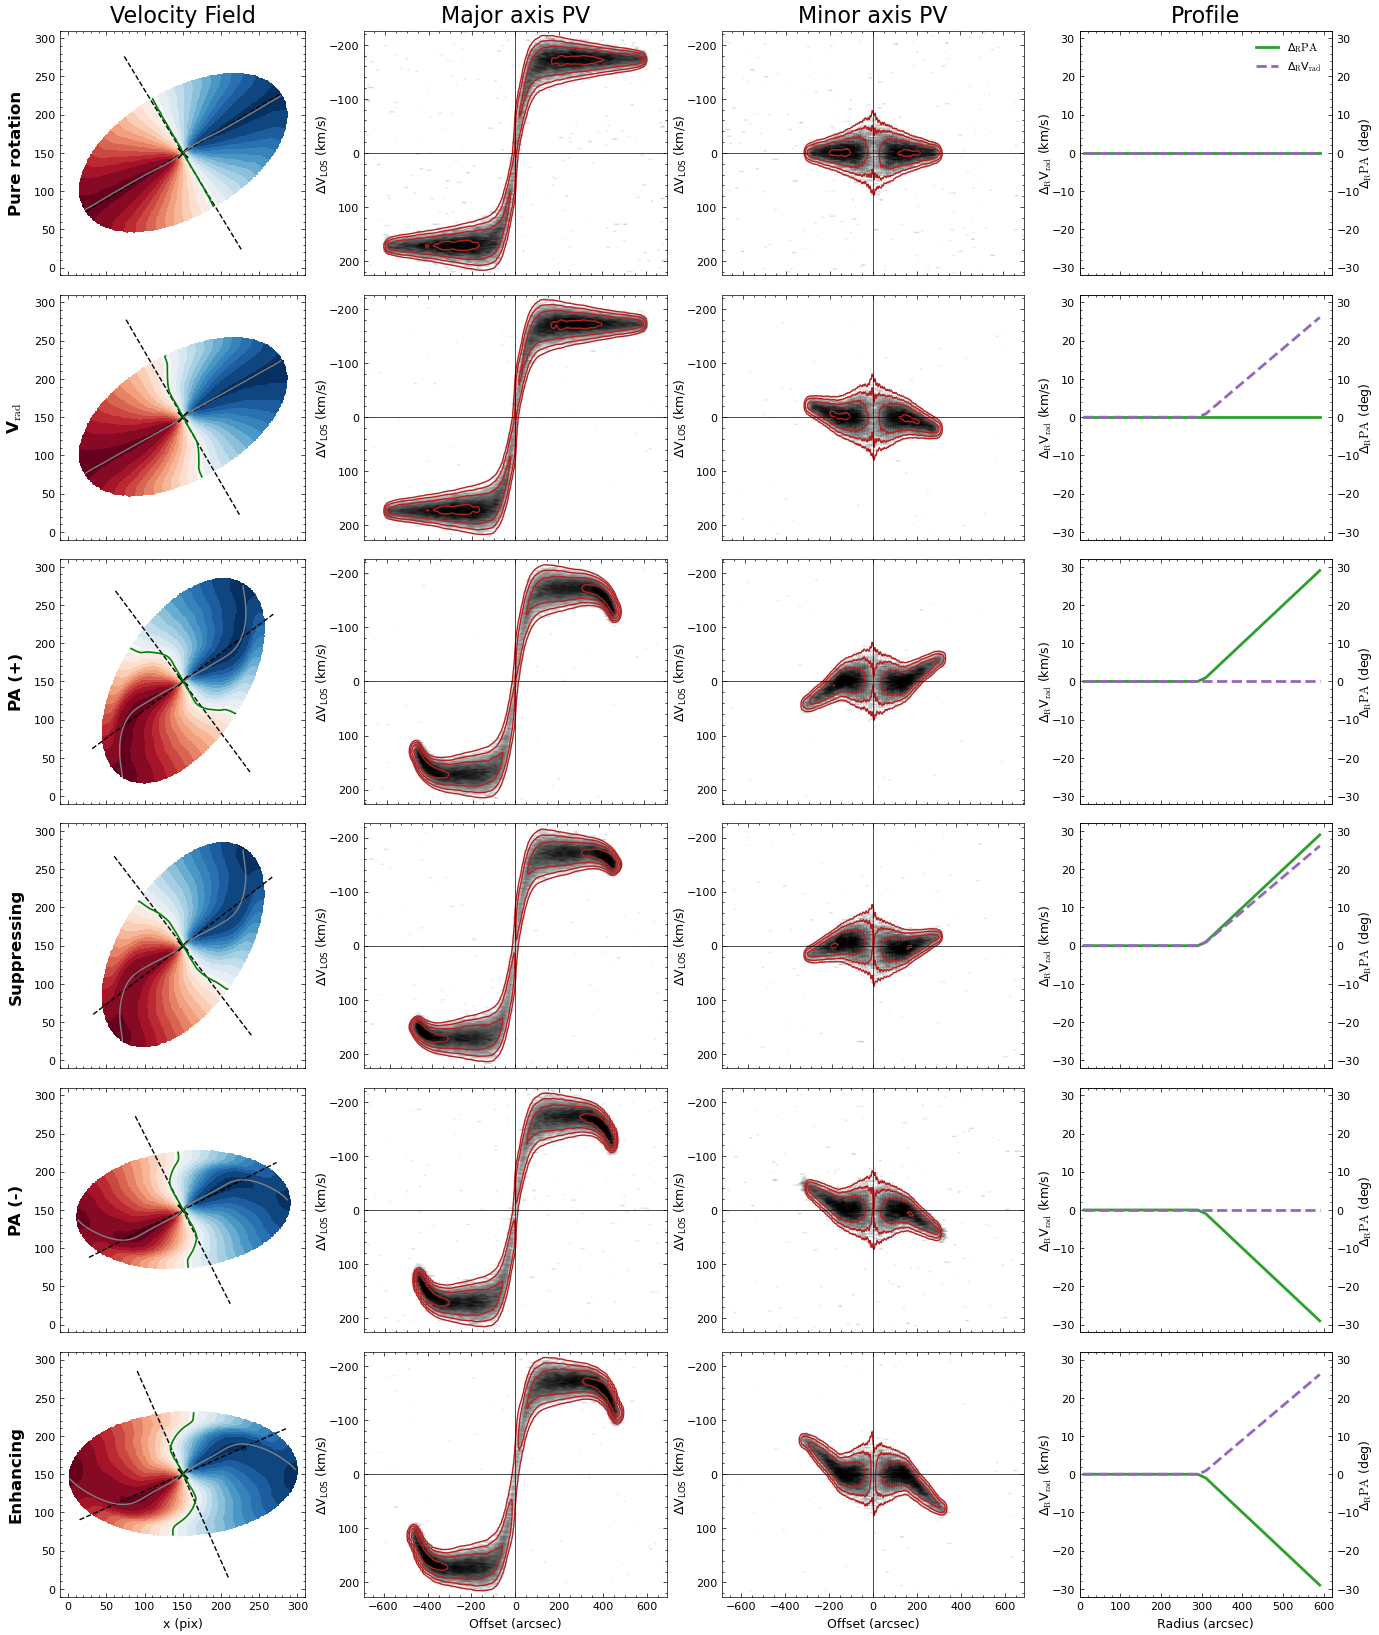

In [49]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import ColorbarBase
from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from copy import copy
import warnings
import glob

# ================= 基础设置 =================
warnings.filterwarnings("ignore")
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
plt.rc('font', family='sans-serif', serif='Helvetica', size=10)
mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)
mpl.rcParams['xtick.labelsize'] = 8
mpl.rcParams['ytick.labelsize'] = 8
mpl.rcParams['axes.labelsize'] = 9
mpl.rcParams['contour.negative_linestyle'] = 'solid'

params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'}
plt.rcParams.update(params)

# ★★★ 请根据服务器修改此处 ★★★
base_path = '/net/'  

# ================= 模型路径配置 =================
models_raw = [
    ("Pure rotation", "dataserver3/data/users/linn/para_Barolo/test_more_model/ring_v200_R50_PAfixed_VR0_INC60/second_step_check_sinw/"),
    (r"$V_{\rm rad}$", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAfixed_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA (+)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VR0_INC60/second_step_check_sinw/"),
    ("Suppressing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA (-)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VR0_INC60/second_step_check_sinw/SNR10Res10mod_maps_azim.pdf"), 
    ("Enhancing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/")
]

# 1. 清洗路径 (处理 pdf 结尾, 拼接 base_path)
models_clean = []
for title, path in models_raw:
    if path.endswith('.pdf'):
        path = os.path.dirname(path) + '/'
    if not path.endswith('/'):
        path += '/'
    full_path = os.path.join(base_path, path)
    models_clean.append((title, full_path))

# 保持顺序
models_ordered = models_clean

# ================= 全局参数 =================
gname = 'SNR10Res10mod'
xmin, xmax = 250, 550
ymin, ymax = 250, 550
zmin, zmax = 10, 190
twostage = 1 
cmap_vel = plt.get_cmap('RdBu_r', 25)

# ================= 辅助函数定义 =================

def get_rings_data(outfolder):
    """读取 rings_final2.txt 获取详细几何参数(PA array, Rad array等)用于画线"""
    fname = 'rings_final2.txt' if twostage else 'rings_final1.txt'
    path = os.path.join(outfolder, fname)
    try:
        # 读取列: 1:Rad, 4:Inc, 5:PA, 9:Xpos, 10:Ypos, 11:Vsys
        data = np.genfromtxt(path, usecols=(1, 4, 5, 9, 10, 11), unpack=True)
        rad, inc, pa, xpos, ypos, vsys = data
        
        return {
            'rad': rad, 'pa': pa, 
            'vsys_m': np.nanmean(vsys),
            'xcen_m': np.nanmean(xpos),
            'ycen_m': np.nanmean(ypos),
            'pa_m': np.nanmean(pa),
            'inc_m': np.nanmean(inc)
        }
    except Exception as e:
        print(f"Error reading rings from {path}: {e}")
        return None

def plot_mom1(ax, outfolder, p_data, is_bottom_row):
    """
    第1列：Data Velocity Field
    包含：Global Major(黑虚), Warped Axis(灰实/点), Green Contour(V=0)
    """
    if p_data is None: 
        ax.text(0.5,0.5, "No Rings Data", ha='center')
        return None, None
    
    # 解包数据
    vsys_m = p_data['vsys_m']
    xcen = p_data['xcen_m'] - xmin
    ycen = p_data['ycen_m'] - ymin
    rad = p_data['rad']
    pa = p_data['pa']
    pa_m = p_data['pa_m']
    
    # 读取 Data Map (注意：这里读取的是 DATA 的 mom1)
    fpath = os.path.join(outfolder, 'maps', gname + '_azim_1mom.fits')
    f1 = fits.open(fpath)
    mom1 = f1[0].data[-10+ymin:ymax+10, -10+xmin:xmax+10]
    f1.close()
    
    data_to_plot = mom1 - vsys_m
    ext = [0, xmax - xmin, 0, ymax - ymin]

    # Normalize
    interval = PercentileInterval(100)
    vmin, vmax = interval.get_limits(data_to_plot)
    vabs = max(abs(vmin), abs(vmax))
    norm = mpl.colors.Normalize(vmin=-vabs-10, vmax=vabs+10)
    
    cmap = copy(cmap_vel)
    cmap.set_bad('w', 1.)
    
    # 绘图
    im = ax.imshow(data_to_plot, origin='lower', cmap=cmap, norm=norm, aspect='equal', extent=ext, interpolation='nearest')
    ax.plot(xcen, ycen, 'x', color='#000000', markersize=7, mew=1.5)

    # --- 绘制辅助线 (基于您的代码逻辑) ---
    x_grid = np.arange(0, xmax - xmin, 0.1)
    
    # 1. Global Major Axis (Black Dashed)
    # y_maj = np.tan(np.radians(pa_m - 90)) * (x_grid - xcen) + ycen
    # ax.plot(x_grid, y_maj, '--', color='k', linewidth=1, alpha=0.8)
    rad_pix = rad / 4.0
    r_line = np.linspace(-max(rad_pix), max(rad_pix), 1000)
    
    x_line = r_line * np.cos(np.radians(pa_m - 90)) + xcen
    y_line = r_line * np.sin(np.radians(pa_m - 90)) + ycen
    
    ax.plot(x_line, y_line, '--', color='k', linewidth=1)
    # 2. Global Minor Axis (Grey Solid)
    # y_min = np.tan(np.radians(pa_m)) * (x_grid - xcen) + ycen
    # ax.plot(x_grid, y_min, '--', color='k', linewidth=1, alpha=0.8)
    x_line_min = -r_line * np.cos(np.radians(pa_m )) + xcen
    y_line_min = -r_line * np.sin(np.radians(pa_m)) + ycen
    
    ax.plot(x_line_min, y_line_min, '--', color='k', linewidth=1)
    ax.set_xlim(-10, xmax - xmin+10)
    ax.set_ylim(-10, ymax - ymin+10)
    
    # 去除 ticks 和 labels
    # ax.set_xticks([])
    # ax.set_yticks([])
    
    if is_bottom_row:
        ax.set_xlabel('x (pix)')
        #ax.set_ylabel('y (pix)')
    else:
        ax.set_xticklabels([])
    

    # 3. Warped Axis / Locus (复用您的代码)
    rad_pix = rad / 4.0  # 您的缩放比例
    try: nr = len(rad_pix)
    except: nr = 1
    
    # 绘制弯曲的 Major Axis
    if nr < 10:
        x_pix = rad_pix * np.cos(np.radians(pa_m - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_m - 90))
        ax.scatter(x_pix + xcen, y_pix + ycen, c='grey', s=12)
        ax.scatter(xcen - x_pix, ycen - y_pix, c='grey', s=12)
    if np.std(pa) < 1e-6:
        pa_use =  pa_m
    else:
        pa_use = pa
    if nr > 5 and not np.all(np.diff(pa) == 0):
        x_pix = rad_pix * np.cos(np.radians(pa_use - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_use - 90))
        ax.plot(xcen - x_pix, ycen - y_pix, '-', color='grey', lw=1)
        ax.plot(x_pix + xcen, y_pix + ycen, '-', color='grey', lw=1)

    # 4. Isovelocity Contour (Green, Level=0)
    maskmap = np.copy(mom1)
    maskmap[mom1==mom1] = 1
    ax.contour(data_to_plot * maskmap, levels=[0], colors='green', origin='lower', extent=ext, linewidths=1.2)
    
    # 坐标轴清理
    # 限制显示范围为 Data 切片大小，防止线条画出界
    
    if not os.path.exists(fpath):
        # 尝试读取 local 或 azim 作为替代，如果 data 不存在
        fpath = os.path.join(outfolder, 'maps', gname + '_azim_1mom.fits')
        if not os.path.exists(fpath):
             ax.text(0.5, 0.5, "Data Map Missing", ha='center')
             return None, None

    return im, norm

def plot_pv_hybrid(ax, outfolder, pv_type, p_data, is_left_col, is_bottom):
    """
    第2、3列：PV Diagrams
    背景：Data (Grey)
    Contour：Model (Red only)
    """
    vsys_m = p_data['vsys_m']
    suffix_data = '_pv_a.fits' if pv_type == 'major' else '_pv_b.fits'
    
    # 读取 Data PV
    f_data_path = os.path.join(outfolder, 'pvs', gname + suffix_data)
    if not os.path.exists(f_data_path): 
        ax.text(0.5, 0.5, "Data PV Missing", ha='center')
        return

    f = fits.open(f_data_path)
    head = f[0].header
    
    # WCS 计算
    crpix = head['CRPIX1']
    cdelt = head['CDELT1']
    crval = head['CRVAL1']
    naxis1 = head['NAXIS1']
    xminpv = max(0, np.floor(crpix - 1 - 150))
    xmaxpv = min(naxis1 - 1, np.ceil(crpix - 1 + 150))
    xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
    xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600
    zmin_wcs, zmax_wcs = 262.75, -189.75 # Hardcoded
    
    ext = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]
    data_crop = f[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
    f.close()
    
    # Normalize Data (Greyscale)
    cont = 0.000598286
    interval = PercentileInterval(99.5)
    vmax_norm = interval.get_limits(data_crop)[1]
    if np.isnan(vmax_norm): vmax_norm = cont*10
    norm = ImageNormalize(vmin=cont, vmax=vmax_norm, stretch=PowerStretch(0.5))
    
    ax.imshow(data_crop, origin='lower', cmap=mpl.cm.Greys, norm=norm, extent=ext, aspect='auto')
    
    # 读取并叠加 Model PV (Red Contours)
    suffix_mod = f'pv_{"a" if pv_type=="major" else "b"}_azim.fits'
    # 查找 azim 或 local
    mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))
    if not mod_files:
        suffix_mod = f'pv_{"a" if pv_type=="major" else "b"}_local.fits'
        mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))

    if mod_files:
        f_mod = fits.open(mod_files[0])
        mod_crop = f_mod[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
        v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont
        # 只画红色
        ax.contour(mod_crop, v_levels, origin='lower', linewidths=1, colors='#B22222', extent=ext)
        f_mod.close()
    
    # 辅助线
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    # ax.set_xticks([])
    # ax.set_yticks([])
    
    #Labels
    # if is_left_col:
    ax.set_ylabel(r'$\Delta V_{LOS}$ (km/s)',labelpad=-2)
    # else:
    #     ax.set_yticklabels([])
        
    if is_bottom:
        ax.set_xlabel('Offset (arcsec)')
    else:
        ax.set_xticklabels([])
def get_initial_profile_path(barolo_path):
    """
    将 Barolo 输出路径转换为 Initial Parameter 的 txt 路径
    例如: 
    From: .../para_Barolo/.../ring_v200...INC60/second_step_check_sinw/
    To:   .../para_initial/.../ring_v200...INC60.txt
    """
    # 1. 规范化路径，去除末尾可能存在的 '/'
    p = os.path.normpath(barolo_path)
    
    # 2. 如果路径以 .pdf 结尾，去掉文件名回到目录
    if p.endswith('.pdf'):
        p = os.path.dirname(p)
        
    # 3. 如果末尾是 'second_step_check_sinw'，向上退一级
    if os.path.basename(p) == 'second_step_check_sinw':
        p = os.path.dirname(p)
        
    # 4. 此时 p 应该以 model 文件夹结尾 (e.g., ring_v200...INC60)
    # 替换路径中的 'para_Barolo' 为 'para_initial'
    new_path_base = p.replace('para_Barolo', 'para_initial')
    
    # 5. 加上 .txt 后缀
    txt_path = new_path_base + ".txt"
    
    return txt_path

def plot_real_profile(ax, barolo_path, row_idx, is_bottom_row):
    """
    读取对应的 txt 文件并绘制 PA 和 VRAD 在同一个 Y 轴上
    """
    # 获取转换后的 txt 路径
    txt_path = get_initial_profile_path(barolo_path)
    
    # 检查文件是否存在
    if not os.path.exists(txt_path):
        ax.text(0.5, 0.5, "Txt Not Found", ha='center', fontsize=8)
        print(f"Missing: {txt_path}")
        return

    try:
        # --- 数据读取部分 (保持不变) ---
        try:
            data = np.genfromtxt(txt_path, names=True, encoding=None)
            colnames = [n.upper() for n in data.dtype.names]
            col_rad = next(n for n in colnames if 'RAD' in n)
            col_pa  = next(n for n in colnames if 'P.A' in n or 'PA' in n)
            col_vrad= next(n for n in colnames if 'VRAD' in n)
            
            rad  = data[data.dtype.names[colnames.index(col_rad)]]
            pa   = data[data.dtype.names[colnames.index(col_pa)]]
            vrad = data[data.dtype.names[colnames.index(col_vrad)]]
        except:
            data_arr = np.genfromtxt(txt_path)
            rad  = data_arr[:, 0]
            pa   = data_arr[:, 1]
            vrad = data_arr[:, 2]

        # === 开始绘图 ===
        color_pa = '#2ca02c'   # Green
        color_vr = '#9467bd'   # Purple
        
        # 数据处理
        pa = pa - 120 

        # 1. 绘制 P.A. (实线) -> 使用 ax
        ax.plot(rad, pa, '-', color=color_pa, lw=2, label=r'$\Delta_{\rm R} \rm{PA}$ ')
        
        # 2. 绘制 VRAD (虚线) -> 同样使用 ax (去掉 twinx)
        ax.plot(rad, vrad, '--', color=color_vr, lw=2, label=r'$\Delta_{\rm R} V_{\rm{rad}}$')
        
        # 设置 X 轴范围
        ax.set_xlim(left=0, right=np.max(rad)*1.05)
        
        # 设置 Y 轴范围 (自动适应两条线的数据)
        # 获取两组数据的最大最小值来设定范围，或者让 matplotlib 自动处理
        all_y = np.concatenate([pa, vrad])
        if len(all_y) > 0:
            y_min, y_max = np.min(all_y), np.max(all_y)
            margin = (y_max - y_min) * 0.1
            ax.set_ylim(-32, 32)

        #ax.grid(True, ls=':', alpha=0.5)

        # Labels
        if is_bottom_row:
            ax.set_xlabel('Radius (arcsec)')
        else:
            ax.tick_params(labelbottom=False)
        ax.set_ylabel(r'$\Delta_{\rm R} V_{\rm{rad}}$ (km/s)',labelpad=-2)
        ax2 = ax.twinx()
        ax2.set_ylim(-32, 32)
        ax2.set_ylabel(r'$\Delta_{\rm R} \rm{PA}$ (deg)',labelpad=-2)
        
        # === 关键修改：单轴图例 ===
        if row_idx == 0:
            # 既然共用一个轴，就不写具体的单位 Label 了，或者写个通用的
             
            
            # 直接显示图例，包含单位
            ax.legend(loc='upper right', fontsize=8, frameon=False)
        else:
            # 其他行如果不需要显示Y轴刻度数字，可以去掉
            # ax.set_yticklabels([]) 
            pass
        #ax.set_xticks([])
    except Exception as e:
        ax.text(0.5, 0.5, "Read Error", ha='center', fontsize=8)
        print(f"Error reading {txt_path}: {e}")
# ================= 主程序执行 =================

fig = plt.figure(figsize=(15, 18))
# 4列: Map | PV Major | PV Minor | Profile
gs = gridspec.GridSpec(6, 4, width_ratios=[1, 1.2, 1.2, 1], wspace=0.2, hspace=0.08)
rows = 6

global_im, global_norm = None, None

for i in range(rows):
    title, path = models_ordered[i]
    is_bottom = (i == rows - 1)
    print(f"Plotting Row {i+1}: {title}...")
    
    # 获取详细数据用于画线
    p_data = get_rings_data(path)
    if p_data is None: 
        print(f"Skipping row {i} (no data)")
        continue
    
    # --- 1. Data Velocity Field ---
    ax0 = fig.add_subplot(gs[i, 0])
    # 传入 p_data 以绘制 Major/Minor 轴
    im, norm = plot_mom1(ax0, path, p_data, is_bottom_row=is_bottom)
    if i == 0: 
        global_im, global_norm = im, norm
        ax0.set_title("Velocity Field")
    
    # 行标题 (左侧)
    ax0.text(-0.15, 0.5, title, transform=ax0.transAxes, 
             va='center', ha='right', fontsize=12, fontweight='bold', rotation=90)

    # --- 2. PV Major (Data=Grey, Model=Red) ---
    ax1 = fig.add_subplot(gs[i, 1])
    plot_pv_hybrid(ax1, path, 'major', p_data, is_left_col=True, is_bottom=is_bottom)
    if i == 0: ax1.set_title("Major axis PV")

    # --- 3. PV Minor (Data=Grey, Model=Red) ---
    ax2 = fig.add_subplot(gs[i, 2])
    plot_pv_hybrid(ax2, path, 'Minor axis PV', p_data, is_left_col=False, is_bottom=is_bottom)
    if i == 0: ax2.set_title("Minor axis PV")
    
    # --- 4. Profile (Placeholder) ---
    ax3 = fig.add_subplot(gs[i, 3])
    plot_real_profile(ax3, path, i, is_bottom)
    if i == 0: ax3.set_title("Profile")
    
# --- 添加 Colorbar (Velocity Field) ---
# if global_im:
#     # 获取最后一行的位置
#     pos_last = fig.add_subplot(gs[rows-1, 0]).get_position()
#     # 在下方添加 colorbar
#     cax = fig.add_axes([pos_last.x0, pos_last.y0 - 0.04, pos_last.width, 0.01])
#     cb = ColorbarBase(cax, orientation='horizontal', cmap=cmap_vel, norm=global_norm)
#     cb.set_label(r'$\Delta V_{LOS}$ (km/s)', fontsize=9)

# 保存文件
output_file = 'Final_Kinematic_Comparison_6x4.pdf'
plt.subplots_adjust(left=0.1, bottom=0.08, right=0.95, top=0.95)
fig.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"Finished. Saved to {output_file}")

Plotting Row 1: Pure rotation...
Plotting Row 2: $V_{\rm rad}$...
Plotting Row 3: PA (+)...
Plotting Row 4: Suppressing...
Plotting Row 5: PA (-)...
Plotting Row 6: Enhancing...
Finished. Saved to Final_Kinematic_Comparison_6x4_test.pdf


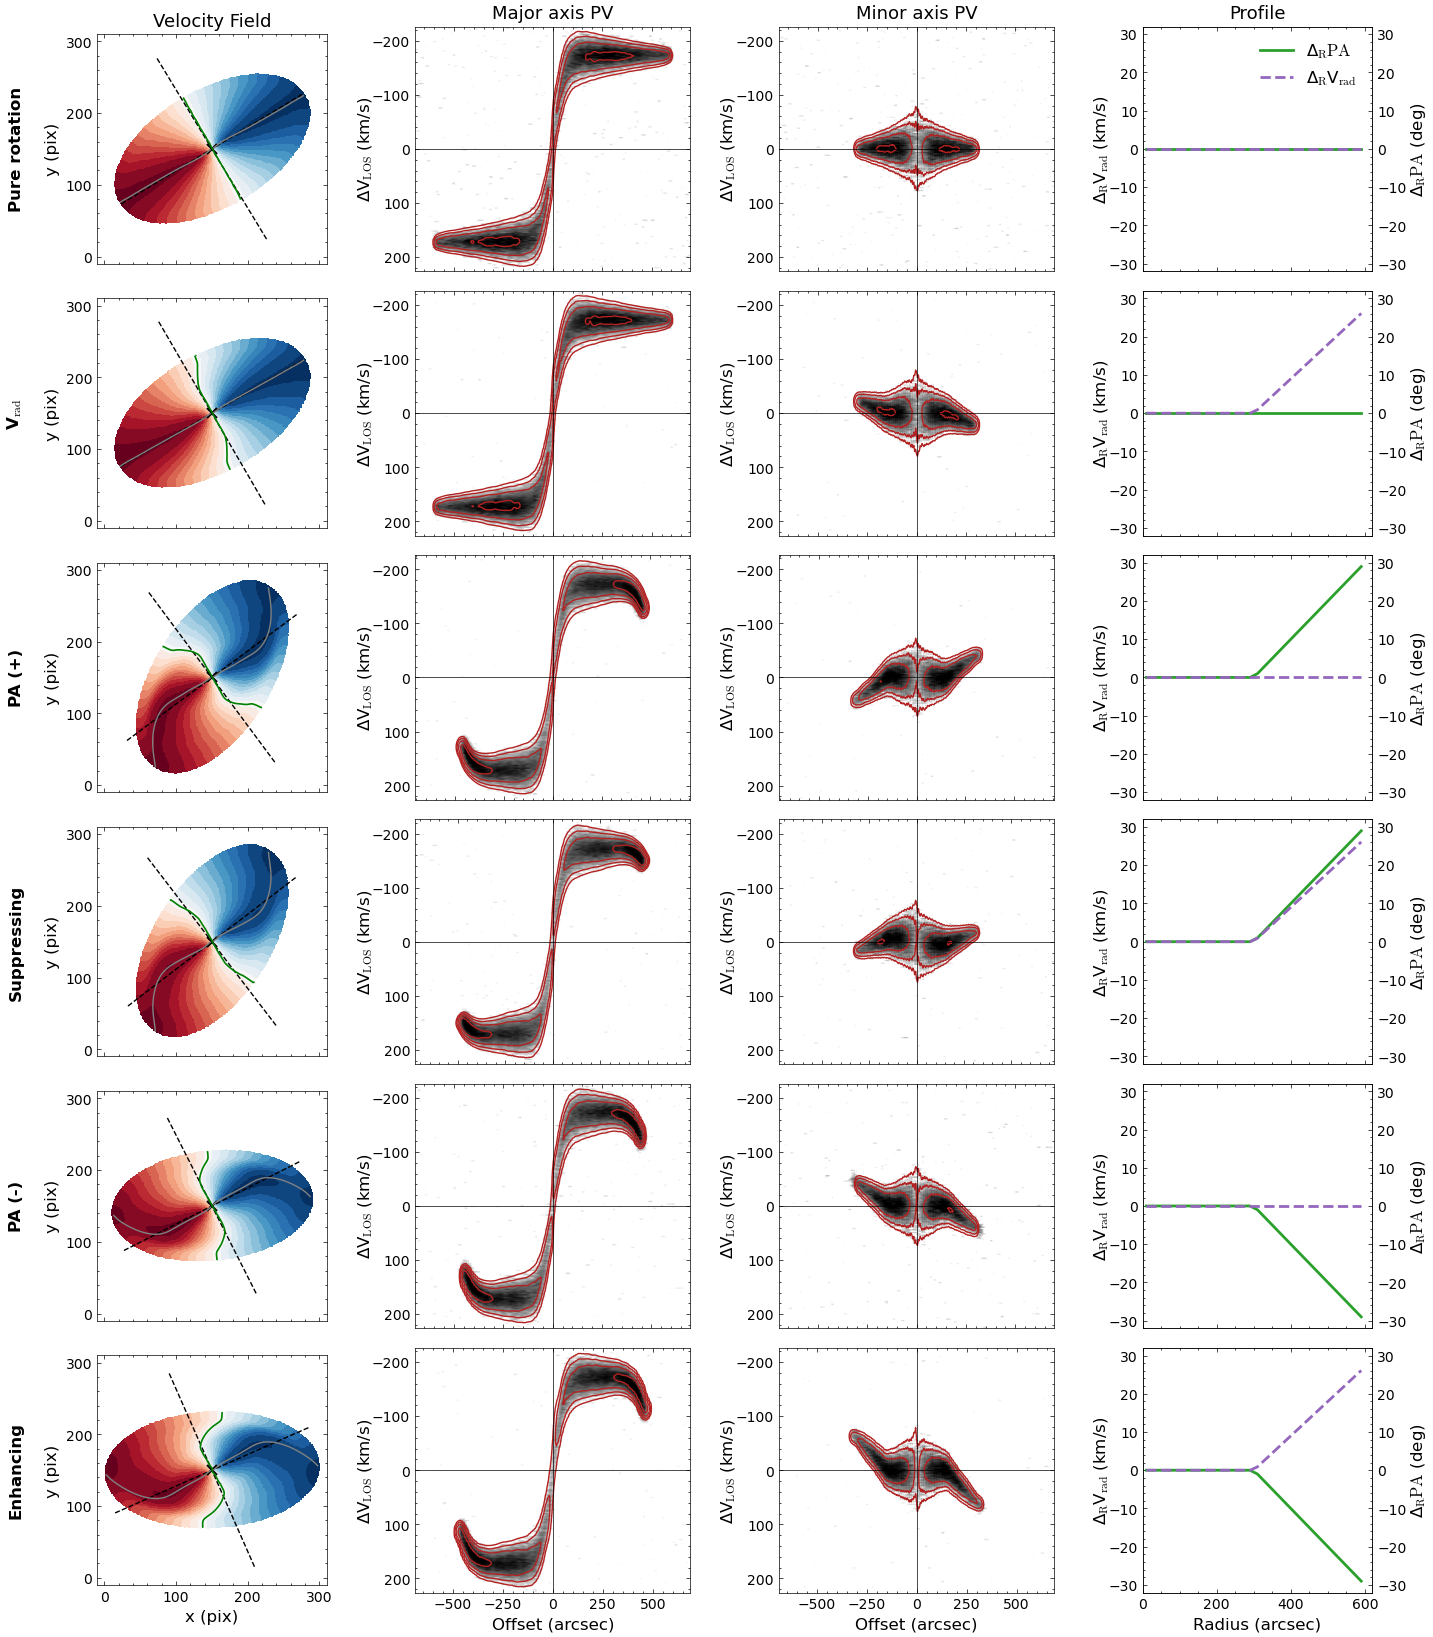

In [3]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import ColorbarBase
from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from copy import copy
import warnings
import glob
from matplotlib.ticker import MultipleLocator
# ================= 基础设置 =================
warnings.filterwarnings("ignore")
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
plt.rc('font', family='sans-serif', serif='Helvetica', size=11)
mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)

mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['contour.negative_linestyle'] = 'solid'

params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'}
plt.rcParams.update(params)
# ★★★ 请根据服务器修改此处 ★★★
base_path = '/net/'  

# ================= 模型路径配置 =================
models_raw = [
    ("Pure rotation", "dataserver3/data/users/linn/para_Barolo/test_more_model/ring_v200_R50_PAfixed_VR0_INC60/second_step_check_sinw/"),
    (r"$V_{\rm rad}$", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAfixed_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA (+)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VR0_INC60/second_step_check_sinw/"),
    ("Suppressing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA (-)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VR0_INC60/second_step_check_sinw/SNR10Res10mod_maps_azim.pdf"), 
    ("Enhancing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/")
]

# 1. 清洗路径 (处理 pdf 结尾, 拼接 base_path)
models_clean = []
for title, path in models_raw:
    if path.endswith('.pdf'):
        path = os.path.dirname(path) + '/'
    if not path.endswith('/'):
        path += '/'
    full_path = os.path.join(base_path, path)
    models_clean.append((title, full_path))

# 保持顺序
models_ordered = models_clean

# ================= 全局参数 =================
gname = 'SNR10Res10mod'
xmin, xmax = 250, 550
ymin, ymax = 250, 550
zmin, zmax = 10, 190
twostage = 1 
cmap_vel = plt.get_cmap('RdBu_r', 25)

# ================= 辅助函数定义 =================

def get_rings_data(outfolder):
    """读取 rings_final2.txt 获取详细几何参数(PA array, Rad array等)用于画线"""
    fname = 'rings_final2.txt' if twostage else 'rings_final1.txt'
    path = os.path.join(outfolder, fname)
    try:
        # 读取列: 1:Rad, 4:Inc, 5:PA, 9:Xpos, 10:Ypos, 11:Vsys
        data = np.genfromtxt(path, usecols=(1, 4, 5, 9, 10, 11), unpack=True)
        rad, inc, pa, xpos, ypos, vsys = data
        
        return {
            'rad': rad, 'pa': pa, 
            'vsys_m': np.nanmean(vsys),
            'xcen_m': np.nanmean(xpos),
            'ycen_m': np.nanmean(ypos),
            'pa_m': np.nanmean(pa),
            'inc_m': np.nanmean(inc)
        }
    except Exception as e:
        print(f"Error reading rings from {path}: {e}")
        return None

def plot_mom1(ax, outfolder, p_data, is_bottom_row):
    """
    第1列：Data Velocity Field
    包含：Global Major/Minor axis, warped axis, V=0 contour
    """
    if p_data is None: 
        ax.text(0.5, 0.5, "No Rings Data", ha='center')
        return None, None
    
    vsys_m = p_data['vsys_m']
    xcen = p_data['xcen_m'] - xmin
    ycen = p_data['ycen_m'] - ymin
    rad = p_data['rad']
    pa = p_data['pa']
    pa_m = p_data['pa_m']
    
    fpath = os.path.join(outfolder, 'maps', gname + '_azim_1mom.fits')
    f1 = fits.open(fpath)
    mom1 = f1[0].data[-10+ymin:ymax+10, -10+xmin:xmax+10]
    f1.close()
    
    data_to_plot = mom1 - vsys_m
    ext = [0, xmax - xmin, 0, ymax - ymin]

    interval = PercentileInterval(100)
    vmin, vmax = interval.get_limits(data_to_plot)
    vabs = max(abs(vmin), abs(vmax))
    norm = mpl.colors.Normalize(vmin=-vabs-10, vmax=vabs+10)
    
    cmap = copy(cmap_vel)
    cmap.set_bad('w', 1.)
    
    im = ax.imshow(
        data_to_plot, origin='lower', cmap=cmap, norm=norm,
        aspect='equal', extent=ext, interpolation='nearest'
    )
    ax.plot(xcen, ycen, 'x', color='#000000', markersize=7, mew=1.5)

    rad_pix = rad / 4.0
    r_line = np.linspace(-max(rad_pix), max(rad_pix), 1000)
    
    x_line = r_line * np.cos(np.radians(pa_m - 90)) + xcen
    y_line = r_line * np.sin(np.radians(pa_m - 90)) + ycen
    ax.plot(x_line, y_line, '--', color='k', linewidth=1)

    x_line_min = -r_line * np.cos(np.radians(pa_m)) + xcen
    y_line_min = -r_line * np.sin(np.radians(pa_m)) + ycen
    ax.plot(x_line_min, y_line_min, '--', color='k', linewidth=1)

    ax.set_xlim(-10, xmax - xmin + 10)
    ax.set_ylim(-10, ymax - ymin + 10)
    
    if is_bottom_row:
        ax.set_xlabel('x (pix)', fontsize=12)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel('y (pix)', fontsize=12)

    try:
        nr = len(rad_pix)
    except:
        nr = 1
    
    if nr < 10:
        x_pix = rad_pix * np.cos(np.radians(pa_m - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_m - 90))
        ax.scatter(x_pix + xcen, y_pix + ycen, c='grey', s=12)
        ax.scatter(xcen - x_pix, ycen - y_pix, c='grey', s=12)

    if np.std(pa) < 1e-6:
        pa_use = pa_m
    else:
        pa_use = pa

    if nr > 5 and not np.all(np.diff(pa) == 0):
        x_pix = rad_pix * np.cos(np.radians(pa_use - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_use - 90))
        ax.plot(xcen - x_pix, ycen - y_pix, '-', color='grey', lw=1)
        ax.plot(x_pix + xcen, y_pix + ycen, '-', color='grey', lw=1)

    maskmap = np.copy(mom1)
    maskmap[mom1 == mom1] = 1
    ax.contour(
        data_to_plot * maskmap, levels=[0], colors='green',
        origin='lower', extent=ext, linewidths=1.2
    )

    return im, norm

def plot_pv_hybrid(ax, outfolder, pv_type, p_data, is_left_col, is_bottom):
    """
    第2、3列：PV Diagrams
    背景：Data grey scale
    Contour：Model red contour
    """
    vsys_m = p_data['vsys_m']

    suffix_data = '_pv_a.fits' if pv_type == 'major' else '_pv_b.fits'
    f_data_path = os.path.join(outfolder, 'pvs', gname + suffix_data)

    if not os.path.exists(f_data_path): 
        ax.text(0.5, 0.5, "Data PV Missing", ha='center')
        return

    f = fits.open(f_data_path)
    head = f[0].header
    
    crpix = head['CRPIX1']
    cdelt = head['CDELT1']
    crval = head['CRVAL1']
    naxis1 = head['NAXIS1']

    xminpv = max(0, np.floor(crpix - 1 - 150))
    xmaxpv = min(naxis1 - 1, np.ceil(crpix - 1 + 150))

    xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
    xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600

    zmin_wcs, zmax_wcs = 262.75, -189.75
    ext = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]

    data_crop = f[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
    f.close()
    
    cont = 0.000598286
    interval = PercentileInterval(99.5)
    vmax_norm = interval.get_limits(data_crop)[1]

    if np.isnan(vmax_norm):
        vmax_norm = cont * 10

    norm = ImageNormalize(vmin=cont, vmax=vmax_norm, stretch=PowerStretch(0.5))
    
    ax.imshow(
        data_crop, origin='lower', cmap=mpl.cm.Greys, norm=norm,
        extent=ext, aspect='auto'
    )
    
    suffix_mod = f'pv_{"a" if pv_type == "major" else "b"}_azim.fits'
    mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))

    if not mod_files:
        suffix_mod = f'pv_{"a" if pv_type == "major" else "b"}_local.fits'
        mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))

    if mod_files:
        f_mod = fits.open(mod_files[0])
        mod_crop = f_mod[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
        v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont
        ax.contour(
            mod_crop, v_levels, origin='lower',
            linewidths=1, colors='#B22222', extent=ext
        )
        f_mod.close()
    
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    
    ax.set_ylabel(r'$\Delta V_{\rm LOS}$ (km/s)', fontsize=12, labelpad=-2)
    
    if is_bottom:
        ax.set_xlabel('Offset (arcsec)', fontsize=12)
    else:
        ax.set_xticklabels([])
def get_initial_profile_path(barolo_path):
    """
    将 Barolo 输出路径转换为 Initial Parameter 的 txt 路径
    例如: 
    From: .../para_Barolo/.../ring_v200...INC60/second_step_check_sinw/
    To:   .../para_initial/.../ring_v200...INC60.txt
    """
    # 1. 规范化路径，去除末尾可能存在的 '/'
    p = os.path.normpath(barolo_path)
    
    # 2. 如果路径以 .pdf 结尾，去掉文件名回到目录
    if p.endswith('.pdf'):
        p = os.path.dirname(p)
        
    # 3. 如果末尾是 'second_step_check_sinw'，向上退一级
    if os.path.basename(p) == 'second_step_check_sinw':
        p = os.path.dirname(p)
        
    # 4. 此时 p 应该以 model 文件夹结尾 (e.g., ring_v200...INC60)
    # 替换路径中的 'para_Barolo' 为 'para_initial'
    new_path_base = p.replace('para_Barolo', 'para_initial')
    
    # 5. 加上 .txt 后缀
    txt_path = new_path_base + ".txt"
    
    return txt_path

def plot_real_profile(ax, barolo_path, row_idx, is_bottom_row):
    """
    读取对应的 initial txt 文件，并绘制 PA 和 VRAD profile
    """
    txt_path = get_initial_profile_path(barolo_path)
    
    if not os.path.exists(txt_path):
        ax.text(0.5, 0.5, "Txt Not Found", ha='center', fontsize=8)
        print(f"Missing: {txt_path}")
        return

    try:
        try:
            data = np.genfromtxt(txt_path, names=True, encoding=None)
            colnames = [n.upper() for n in data.dtype.names]

            col_rad = next(n for n in colnames if 'RAD' in n)
            col_pa = next(n for n in colnames if 'P.A' in n or 'PA' in n)
            col_vrad = next(n for n in colnames if 'VRAD' in n)
            
            rad = data[data.dtype.names[colnames.index(col_rad)]]
            pa = data[data.dtype.names[colnames.index(col_pa)]]
            vrad = data[data.dtype.names[colnames.index(col_vrad)]]

        except:
            data_arr = np.genfromtxt(txt_path)
            rad = data_arr[:, 0]
            pa = data_arr[:, 1]
            vrad = data_arr[:, 2]

        color_pa = '#2ca02c'
        color_vr = '#9467bd'
        
        pa = pa - 120 

        ax.plot(rad, pa, '-', color=color_pa, lw=2, label=r'$\Delta_{\rm R}{\rm PA}$')
        ax.plot(rad, vrad, '--', color=color_vr, lw=2, label=r'$\Delta_{\rm R}V_{\rm rad}$')
        
        ax.set_xlim(left=0, right=np.max(rad) * 1.05)
        ax.set_ylim(-32, 32)

        if is_bottom_row:
            ax.set_xlabel('Radius (arcsec)', fontsize=12)
        else:
            ax.tick_params(labelbottom=False)

        ax.set_ylabel(r'$\Delta_{\rm R}V_{\rm rad}$ (km/s)', fontsize=12, labelpad=-2)

        ax2 = ax.twinx()
        ax2.set_ylim(-32, 32)
        ax2.set_ylabel(r'$\Delta_{\rm R}{\rm PA}$ (deg)', fontsize=12, labelpad=2)
        ax2.tick_params(labelsize=10)

        if row_idx == 0:
            ax.legend(loc='upper right', fontsize=12, frameon=False)

    except Exception as e:
        ax.text(0.5, 0.5, "Read Error", ha='center', fontsize=8)
        print(f"Error reading {txt_path}: {e}")
# ================= 主程序执行 =================

fig = plt.figure(figsize=(15, 18))
# 4列: Map | PV Major | PV Minor | Profile
gs = gridspec.GridSpec(6, 4, width_ratios=[1, 1.2, 1.2, 1], wspace=0.35, hspace=0.08)
rows = 6

global_im, global_norm = None, None

for i in range(rows):
    title, path = models_ordered[i]
    is_bottom = (i == rows - 1)
    print(f"Plotting Row {i+1}: {title}...")
    
    # 获取详细数据用于画线
    p_data = get_rings_data(path)
    if p_data is None: 
        print(f"Skipping row {i} (no data)")
        continue
    
    # --- 1. Data Velocity Field ---
    ax0 = fig.add_subplot(gs[i, 0])
    # 传入 p_data 以绘制 Major/Minor 轴
    im, norm = plot_mom1(ax0, path, p_data, is_bottom_row=is_bottom)
    if i == 0: 
        global_im, global_norm = im, norm
        ax0.set_title("Velocity Field")
    
    # 行标题 (左侧)
    ax0.text(-0.32, 0.5, title, transform=ax0.transAxes, 
             va='center', ha='right', fontsize=12, fontweight='bold', rotation=90)
    ax0.xaxis.set_major_locator(MultipleLocator(100))
    ax0.yaxis.set_major_locator(MultipleLocator(100))   
    # --- 2. PV Major (Data=Grey, Model=Red) ---
    ax1 = fig.add_subplot(gs[i, 1])
    plot_pv_hybrid(ax1, path, 'major', p_data, is_left_col=True, is_bottom=is_bottom)
    if i == 0: ax1.set_title("Major axis PV")

    # --- 3. PV Minor (Data=Grey, Model=Red) ---
    ax2 = fig.add_subplot(gs[i, 2])
    plot_pv_hybrid(ax2, path, 'Minor axis PV', p_data, is_left_col=False, is_bottom=is_bottom)
    if i == 0: ax2.set_title("Minor axis PV")
    
    # --- 4. Profile (Placeholder) ---
    ax3 = fig.add_subplot(gs[i, 3])
    plot_real_profile(ax3, path, i, is_bottom)
    if i == 0: ax3.set_title("Profile")
    
# --- 添加 Colorbar (Velocity Field) ---
# if global_im:
#     # 获取最后一行的位置
#     pos_last = fig.add_subplot(gs[rows-1, 0]).get_position()
#     # 在下方添加 colorbar
#     cax = fig.add_axes([pos_last.x0, pos_last.y0 - 0.04, pos_last.width, 0.01])
#     cb = ColorbarBase(cax, orientation='horizontal', cmap=cmap_vel, norm=global_norm)
#     cb.set_label(r'$\Delta V_{LOS}$ (km/s)', fontsize=9)

# 保存文件
output_file = 'Final_Kinematic_Comparison_6x4_test.pdf'
plt.subplots_adjust(left=0.1, bottom=0.08, right=0.95, top=0.95)
fig.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"Finished. Saved to {output_file}")

Plotting Row 1: Pure rotation...
Plotting Row 2: $V_{\rm rad}$...
Plotting Row 3: PA (+)...
Plotting Row 4: Suppressing...
Plotting Row 5: PA (-)...
Plotting Row 6: Enhancing...
Finished. Saved to Final_Kinematic_Comparison_6x4_test.pdf


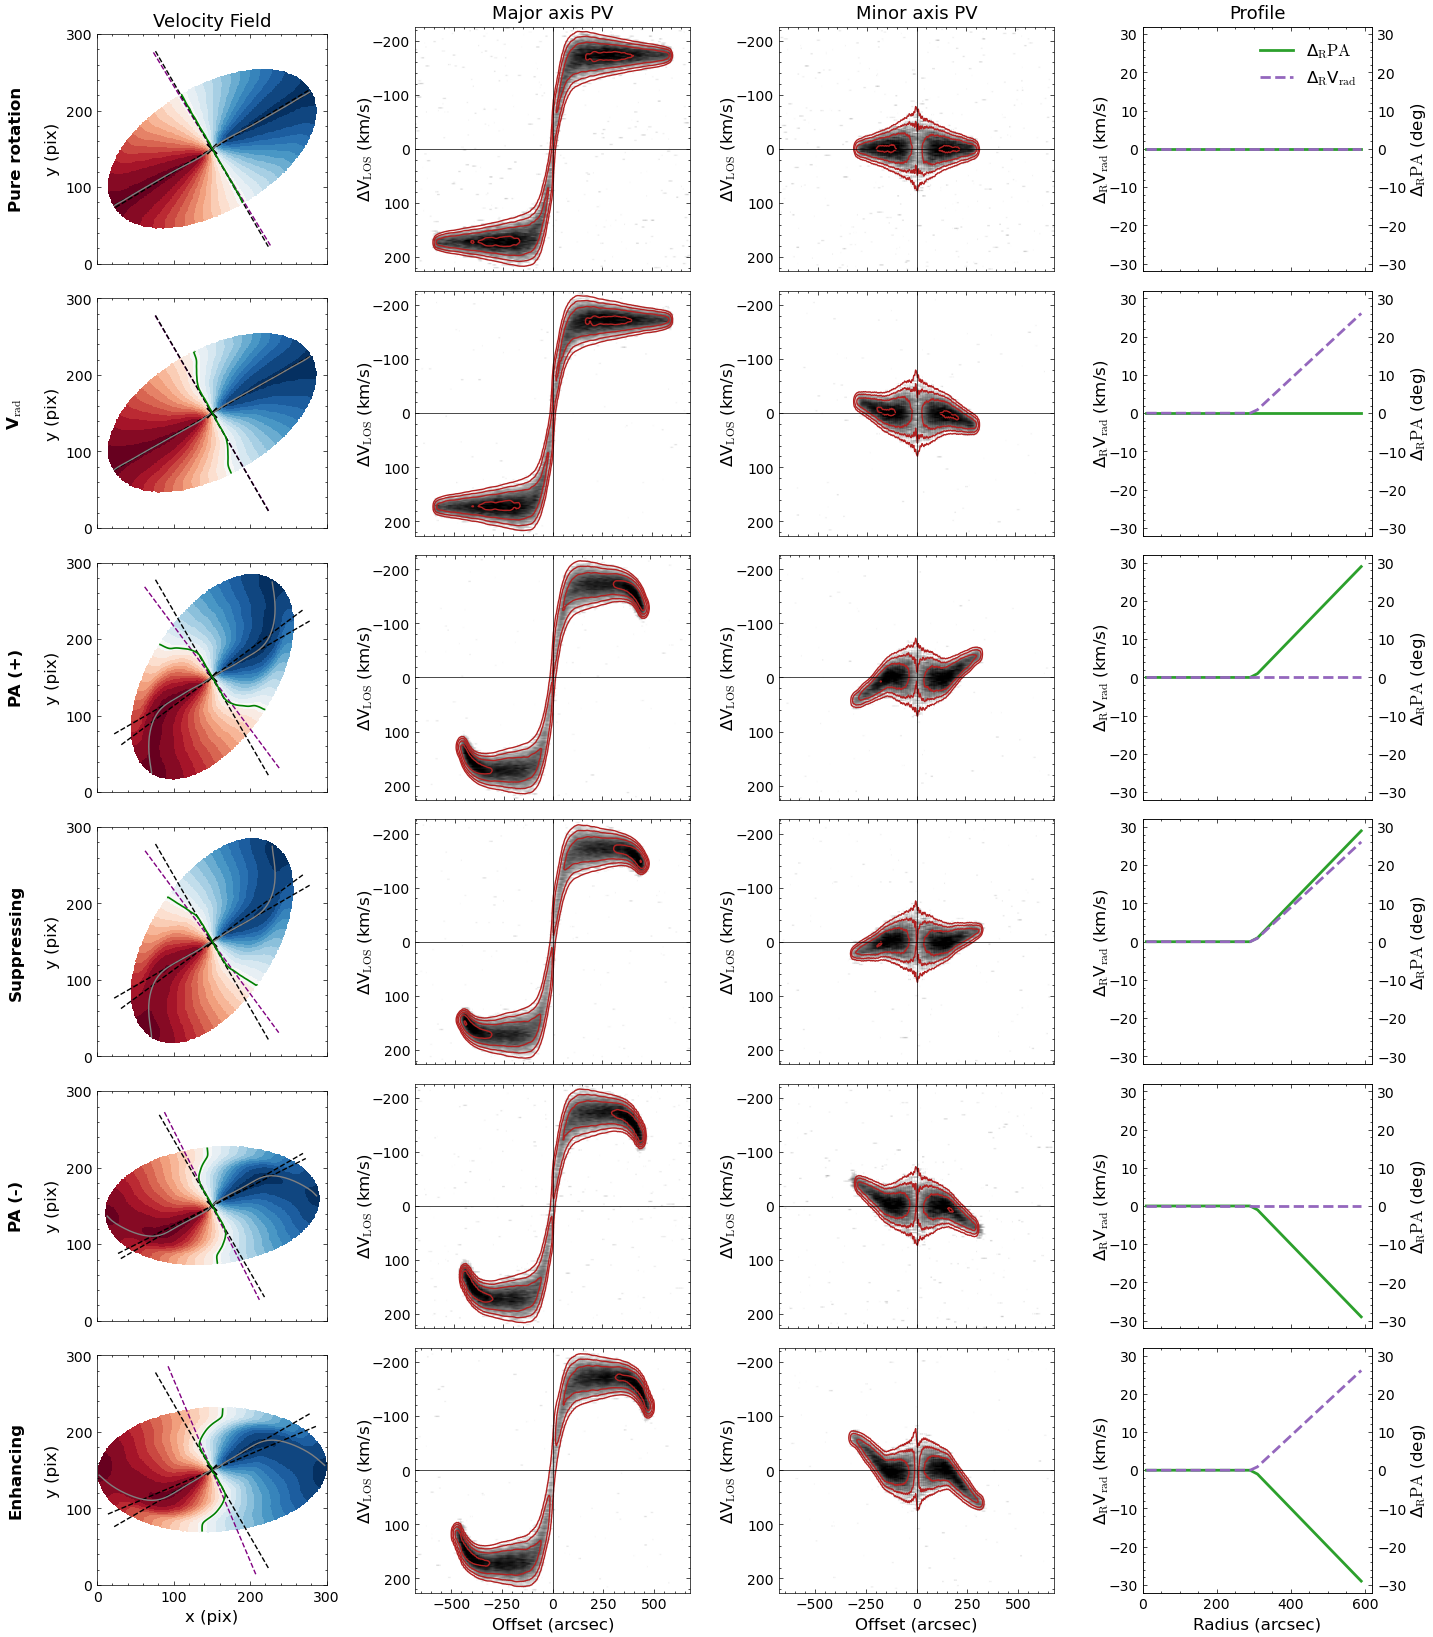

In [1]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import ColorbarBase
from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from copy import copy
import warnings
import glob
from matplotlib.ticker import MultipleLocator
# ================= 基础设置 =================
warnings.filterwarnings("ignore")
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
plt.rc('font', family='sans-serif', serif='Helvetica', size=11)
mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)

mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['contour.negative_linestyle'] = 'solid'

params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'}
plt.rcParams.update(params)
# ★★★ 请根据服务器修改此处 ★★★
base_path = '/net/'  

# ================= 模型路径配置 =================
models_raw = [
    ("Pure rotation", "dataserver3/data/users/linn/para_Barolo/test_more_model/ring_v200_R50_PAfixed_VR0_INC60/second_step_check_sinw/"),
    (r"$V_{\rm rad}$", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAfixed_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA (+)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VR0_INC60/second_step_check_sinw/"),
    ("Suppressing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA (-)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VR0_INC60/second_step_check_sinw/SNR10Res10mod_maps_azim.pdf"), 
    ("Enhancing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/")
]

# 1. 清洗路径 (处理 pdf 结尾, 拼接 base_path)
models_clean = []
for title, path in models_raw:
    if path.endswith('.pdf'):
        path = os.path.dirname(path) + '/'
    if not path.endswith('/'):
        path += '/'
    full_path = os.path.join(base_path, path)
    models_clean.append((title, full_path))

# 保持顺序
models_ordered = models_clean

# ================= 全局参数 =================
gname = 'SNR10Res10mod'
xmin, xmax = 250, 550
ymin, ymax = 250, 550
zmin, zmax = 10, 190
twostage = 1 
cmap_vel = plt.get_cmap('RdBu_r', 25)

# ================= 辅助函数定义 =================

def get_rings_data(outfolder):
    """读取 rings_final2.txt 获取详细几何参数(PA array, Rad array等)用于画线"""
    fname = 'rings_final2.txt' if twostage else 'rings_final1.txt'
    path = os.path.join(outfolder, fname)
    try:
        # 读取列: 1:Rad, 4:Inc, 5:PA, 9:Xpos, 10:Ypos, 11:Vsys
        data = np.genfromtxt(path, usecols=(1, 4, 5, 9, 10, 11), unpack=True)
        rad, inc, pa, xpos, ypos, vsys = data
        
        return {
            'rad': rad, 'pa': pa, 
            'vsys_m': np.nanmean(vsys),
            'xcen_m': np.nanmean(xpos),
            'ycen_m': np.nanmean(ypos),
            'pa_m': np.nanmean(pa),
            'inc_m': np.nanmean(inc)
        }
    except Exception as e:
        print(f"Error reading rings from {path}: {e}")
        return None

def plot_mom1(ax, outfolder, p_data, is_bottom_row):
    """
    第1列：Data Velocity Field
    包含：Global Major/Minor axis, warped axis, V=0 contour
    """
    if p_data is None: 
        ax.text(0.5, 0.5, "No Rings Data", ha='center')
        return None, None
    
    vsys_m = p_data['vsys_m']
    xcen = p_data['xcen_m'] - xmin
    ycen = p_data['ycen_m'] - ymin
    rad = p_data['rad']
    pa = p_data['pa']
    pa_m = p_data['pa_m']
    
    fpath = os.path.join(outfolder, 'maps', gname + '_azim_1mom.fits')
    f1 = fits.open(fpath)
    mom1 = f1[0].data[-10+ymin:ymax+10, -10+xmin:xmax+10]
    f1.close()
    
    data_to_plot = mom1 - vsys_m
    ext = [0, xmax - xmin, 0, ymax - ymin]

    interval = PercentileInterval(100)
    vmin, vmax = interval.get_limits(data_to_plot)
    vabs = max(abs(vmin), abs(vmax))
    norm = mpl.colors.Normalize(vmin=-vabs-10, vmax=vabs+10)
    
    cmap = copy(cmap_vel)
    cmap.set_bad('w', 1.)
    
    im = ax.imshow(
        data_to_plot, origin='lower', cmap=cmap, norm=norm,
        aspect='equal', extent=ext, interpolation='nearest'
    )
    ax.plot(xcen, ycen, 'x', color='#000000', markersize=7, mew=1.5)
    rad_pix = rad / 4.0
    r_line = np.linspace(-max(rad_pix), max(rad_pix), 1000)
    
    x_line = r_line * np.cos(np.radians(pa_m - 90)) + xcen
    y_line = r_line * np.sin(np.radians(pa_m - 90)) + ycen
    ax.plot(x_line, y_line, '--', color='k', linewidth=1)
    
    x_line_min = -r_line * np.cos(np.radians(pa_m)) + xcen
    y_line_min = -r_line * np.sin(np.radians(pa_m)) + ycen
    ax.plot(x_line_min, y_line_min, '--', color='purple', linewidth=1)
    rad_pix = rad / 4.0
    r_line = np.linspace(-max(rad_pix), max(rad_pix), 1000)
    
    # 固定 PA 为 120°（纯旋转无扭曲盘）
    fixed_pa = 120.0
    
    x_line = r_line * np.cos(np.radians(fixed_pa - 90)) + xcen
    y_line = r_line * np.sin(np.radians(fixed_pa - 90)) + ycen
    ax.plot(x_line, y_line, '--', color='k', linewidth=1)
    
    x_line_min = -r_line * np.cos(np.radians(fixed_pa)) + xcen
    y_line_min = -r_line * np.sin(np.radians(fixed_pa)) + ycen
    ax.plot(x_line_min, y_line_min, '--', color='k', linewidth=1)    
    if is_bottom_row:
        ax.set_xlabel('x (pix)', fontsize=12)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel('y (pix)', fontsize=12)

    try:
        nr = len(rad_pix)
    except:
        nr = 1
    
    if nr < 10:
        x_pix = rad_pix * np.cos(np.radians(pa_m - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_m - 90))
        ax.scatter(x_pix + xcen, y_pix + ycen, c='grey', s=12)
        ax.scatter(xcen - x_pix, ycen - y_pix, c='grey', s=12)

    if np.std(pa) < 1e-6:
        pa_use = pa_m
    else:
        pa_use = pa

    if nr > 5 and not np.all(np.diff(pa) == 0):
        x_pix = rad_pix * np.cos(np.radians(pa_use - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_use - 90))
        ax.plot(xcen - x_pix, ycen - y_pix, '-', color='grey', lw=1)
        ax.plot(x_pix + xcen, y_pix + ycen, '-', color='grey', lw=1)

    maskmap = np.copy(mom1)
    maskmap[mom1 == mom1] = 1
    ax.contour(
        data_to_plot * maskmap, levels=[0], colors='green',
        origin='lower', extent=ext, linewidths=1.2
    )

    return im, norm

def plot_pv_hybrid(ax, outfolder, pv_type, p_data, is_left_col, is_bottom):
    """
    第2、3列：PV Diagrams
    背景：Data grey scale
    Contour：Model red contour
    """
    vsys_m = p_data['vsys_m']

    suffix_data = '_pv_a.fits' if pv_type == 'major' else '_pv_b.fits'
    f_data_path = os.path.join(outfolder, 'pvs', gname + suffix_data)

    if not os.path.exists(f_data_path): 
        ax.text(0.5, 0.5, "Data PV Missing", ha='center')
        return

    f = fits.open(f_data_path)
    head = f[0].header
    
    crpix = head['CRPIX1']
    cdelt = head['CDELT1']
    crval = head['CRVAL1']
    naxis1 = head['NAXIS1']

    xminpv = max(0, np.floor(crpix - 1 - 150))
    xmaxpv = min(naxis1 - 1, np.ceil(crpix - 1 + 150))

    xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
    xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600

    zmin_wcs, zmax_wcs = 262.75, -189.75
    ext = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]

    data_crop = f[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
    f.close()
    
    cont = 0.000598286
    interval = PercentileInterval(99.5)
    vmax_norm = interval.get_limits(data_crop)[1]

    if np.isnan(vmax_norm):
        vmax_norm = cont * 10

    norm = ImageNormalize(vmin=cont, vmax=vmax_norm, stretch=PowerStretch(0.5))
    
    ax.imshow(
        data_crop, origin='lower', cmap=mpl.cm.Greys, norm=norm,
        extent=ext, aspect='auto'
    )
    
    suffix_mod = f'pv_{"a" if pv_type == "major" else "b"}_azim.fits'
    mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))

    if not mod_files:
        suffix_mod = f'pv_{"a" if pv_type == "major" else "b"}_local.fits'
        mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))

    if mod_files:
        f_mod = fits.open(mod_files[0])
        mod_crop = f_mod[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
        v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont
        ax.contour(
            mod_crop, v_levels, origin='lower',
            linewidths=1, colors='#B22222', extent=ext
        )
        f_mod.close()
    
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    
    ax.set_ylabel(r'$\Delta V_{\rm LOS}$ (km/s)', fontsize=12, labelpad=-2)
    
    if is_bottom:
        ax.set_xlabel('Offset (arcsec)', fontsize=12)
    else:
        ax.set_xticklabels([])
def get_initial_profile_path(barolo_path):
    """
    将 Barolo 输出路径转换为 Initial Parameter 的 txt 路径
    例如: 
    From: .../para_Barolo/.../ring_v200...INC60/second_step_check_sinw/
    To:   .../para_initial/.../ring_v200...INC60.txt
    """
    # 1. 规范化路径，去除末尾可能存在的 '/'
    p = os.path.normpath(barolo_path)
    
    # 2. 如果路径以 .pdf 结尾，去掉文件名回到目录
    if p.endswith('.pdf'):
        p = os.path.dirname(p)
        
    # 3. 如果末尾是 'second_step_check_sinw'，向上退一级
    if os.path.basename(p) == 'second_step_check_sinw':
        p = os.path.dirname(p)
        
    # 4. 此时 p 应该以 model 文件夹结尾 (e.g., ring_v200...INC60)
    # 替换路径中的 'para_Barolo' 为 'para_initial'
    new_path_base = p.replace('para_Barolo', 'para_initial')
    
    # 5. 加上 .txt 后缀
    txt_path = new_path_base + ".txt"
    
    return txt_path

def plot_real_profile(ax, barolo_path, row_idx, is_bottom_row):
    """
    读取对应的 initial txt 文件，并绘制 PA 和 VRAD profile
    """
    txt_path = get_initial_profile_path(barolo_path)
    
    if not os.path.exists(txt_path):
        ax.text(0.5, 0.5, "Txt Not Found", ha='center', fontsize=8)
        print(f"Missing: {txt_path}")
        return

    try:
        try:
            data = np.genfromtxt(txt_path, names=True, encoding=None)
            colnames = [n.upper() for n in data.dtype.names]

            col_rad = next(n for n in colnames if 'RAD' in n)
            col_pa = next(n for n in colnames if 'P.A' in n or 'PA' in n)
            col_vrad = next(n for n in colnames if 'VRAD' in n)
            
            rad = data[data.dtype.names[colnames.index(col_rad)]]
            pa = data[data.dtype.names[colnames.index(col_pa)]]
            vrad = data[data.dtype.names[colnames.index(col_vrad)]]

        except:
            data_arr = np.genfromtxt(txt_path)
            rad = data_arr[:, 0]
            pa = data_arr[:, 1]
            vrad = data_arr[:, 2]

        color_pa = '#2ca02c'
        color_vr = '#9467bd'
        
        pa = pa - 120 

        ax.plot(rad, pa, '-', color=color_pa, lw=2, label=r'$\Delta_{\rm R}{\rm PA}$')
        ax.plot(rad, vrad, '--', color=color_vr, lw=2, label=r'$\Delta_{\rm R}V_{\rm rad}$')
        
        ax.set_xlim(left=0, right=np.max(rad) * 1.05)
        ax.set_ylim(-32, 32)

        if is_bottom_row:
            ax.set_xlabel('Radius (arcsec)', fontsize=12)
        else:
            ax.tick_params(labelbottom=False)

        ax.set_ylabel(r'$\Delta_{\rm R}V_{\rm rad}$ (km/s)', fontsize=12, labelpad=-2)

        ax2 = ax.twinx()
        ax2.set_ylim(-32, 32)
        ax2.set_ylabel(r'$\Delta_{\rm R}{\rm PA}$ (deg)', fontsize=12, labelpad=2)
        ax2.tick_params(labelsize=10)

        if row_idx == 0:
            ax.legend(loc='upper right', fontsize=12, frameon=False)

    except Exception as e:
        ax.text(0.5, 0.5, "Read Error", ha='center', fontsize=8)
        print(f"Error reading {txt_path}: {e}")
# ================= 主程序执行 =================

fig = plt.figure(figsize=(15, 18))
# 4列: Map | PV Major | PV Minor | Profile
gs = gridspec.GridSpec(6, 4, width_ratios=[1, 1.2, 1.2, 1], wspace=0.35, hspace=0.08)
rows = 6

global_im, global_norm = None, None

for i in range(rows):
    title, path = models_ordered[i]
    is_bottom = (i == rows - 1)
    print(f"Plotting Row {i+1}: {title}...")
    
    # 获取详细数据用于画线
    p_data = get_rings_data(path)
    if p_data is None: 
        print(f"Skipping row {i} (no data)")
        continue
    
    # --- 1. Data Velocity Field ---
    ax0 = fig.add_subplot(gs[i, 0])
    # 传入 p_data 以绘制 Major/Minor 轴
    im, norm = plot_mom1(ax0, path, p_data, is_bottom_row=is_bottom)
    if i == 0: 
        global_im, global_norm = im, norm
        ax0.set_title("Velocity Field")
    
    # 行标题 (左侧)
    ax0.text(-0.32, 0.5, title, transform=ax0.transAxes, 
             va='center', ha='right', fontsize=12, fontweight='bold', rotation=90)
    ax0.xaxis.set_major_locator(MultipleLocator(100))
    ax0.yaxis.set_major_locator(MultipleLocator(100))   
    # --- 2. PV Major (Data=Grey, Model=Red) ---
    ax1 = fig.add_subplot(gs[i, 1])
    plot_pv_hybrid(ax1, path, 'major', p_data, is_left_col=True, is_bottom=is_bottom)
    if i == 0: ax1.set_title("Major axis PV")

    # --- 3. PV Minor (Data=Grey, Model=Red) ---
    ax2 = fig.add_subplot(gs[i, 2])
    plot_pv_hybrid(ax2, path, 'Minor axis PV', p_data, is_left_col=False, is_bottom=is_bottom)
    if i == 0: ax2.set_title("Minor axis PV")
    
    # --- 4. Profile (Placeholder) ---
    ax3 = fig.add_subplot(gs[i, 3])
    plot_real_profile(ax3, path, i, is_bottom)
    if i == 0: ax3.set_title("Profile")
    
# --- 添加 Colorbar (Velocity Field) ---
# if global_im:
#     # 获取最后一行的位置
#     pos_last = fig.add_subplot(gs[rows-1, 0]).get_position()
#     # 在下方添加 colorbar
#     cax = fig.add_axes([pos_last.x0, pos_last.y0 - 0.04, pos_last.width, 0.01])
#     cb = ColorbarBase(cax, orientation='horizontal', cmap=cmap_vel, norm=global_norm)
#     cb.set_label(r'$\Delta V_{LOS}$ (km/s)', fontsize=9)

# 保存文件
output_file = 'Final_Kinematic_Comparison_6x4_test.pdf'
plt.subplots_adjust(left=0.1, bottom=0.08, right=0.95, top=0.95)
fig.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"Finished. Saved to {output_file}")

Plotting Row 1: Pure rotation...
Plotting Row 2: $V_{\rm rad}$...
Plotting Row 3: PA (+)...
Plotting Row 4: Suppressing...
Plotting Row 5: PA (-)...
Plotting Row 6: Enhancing...
Finished. Saved to Final_Kinematic_Comparison_6x4_test.pdf


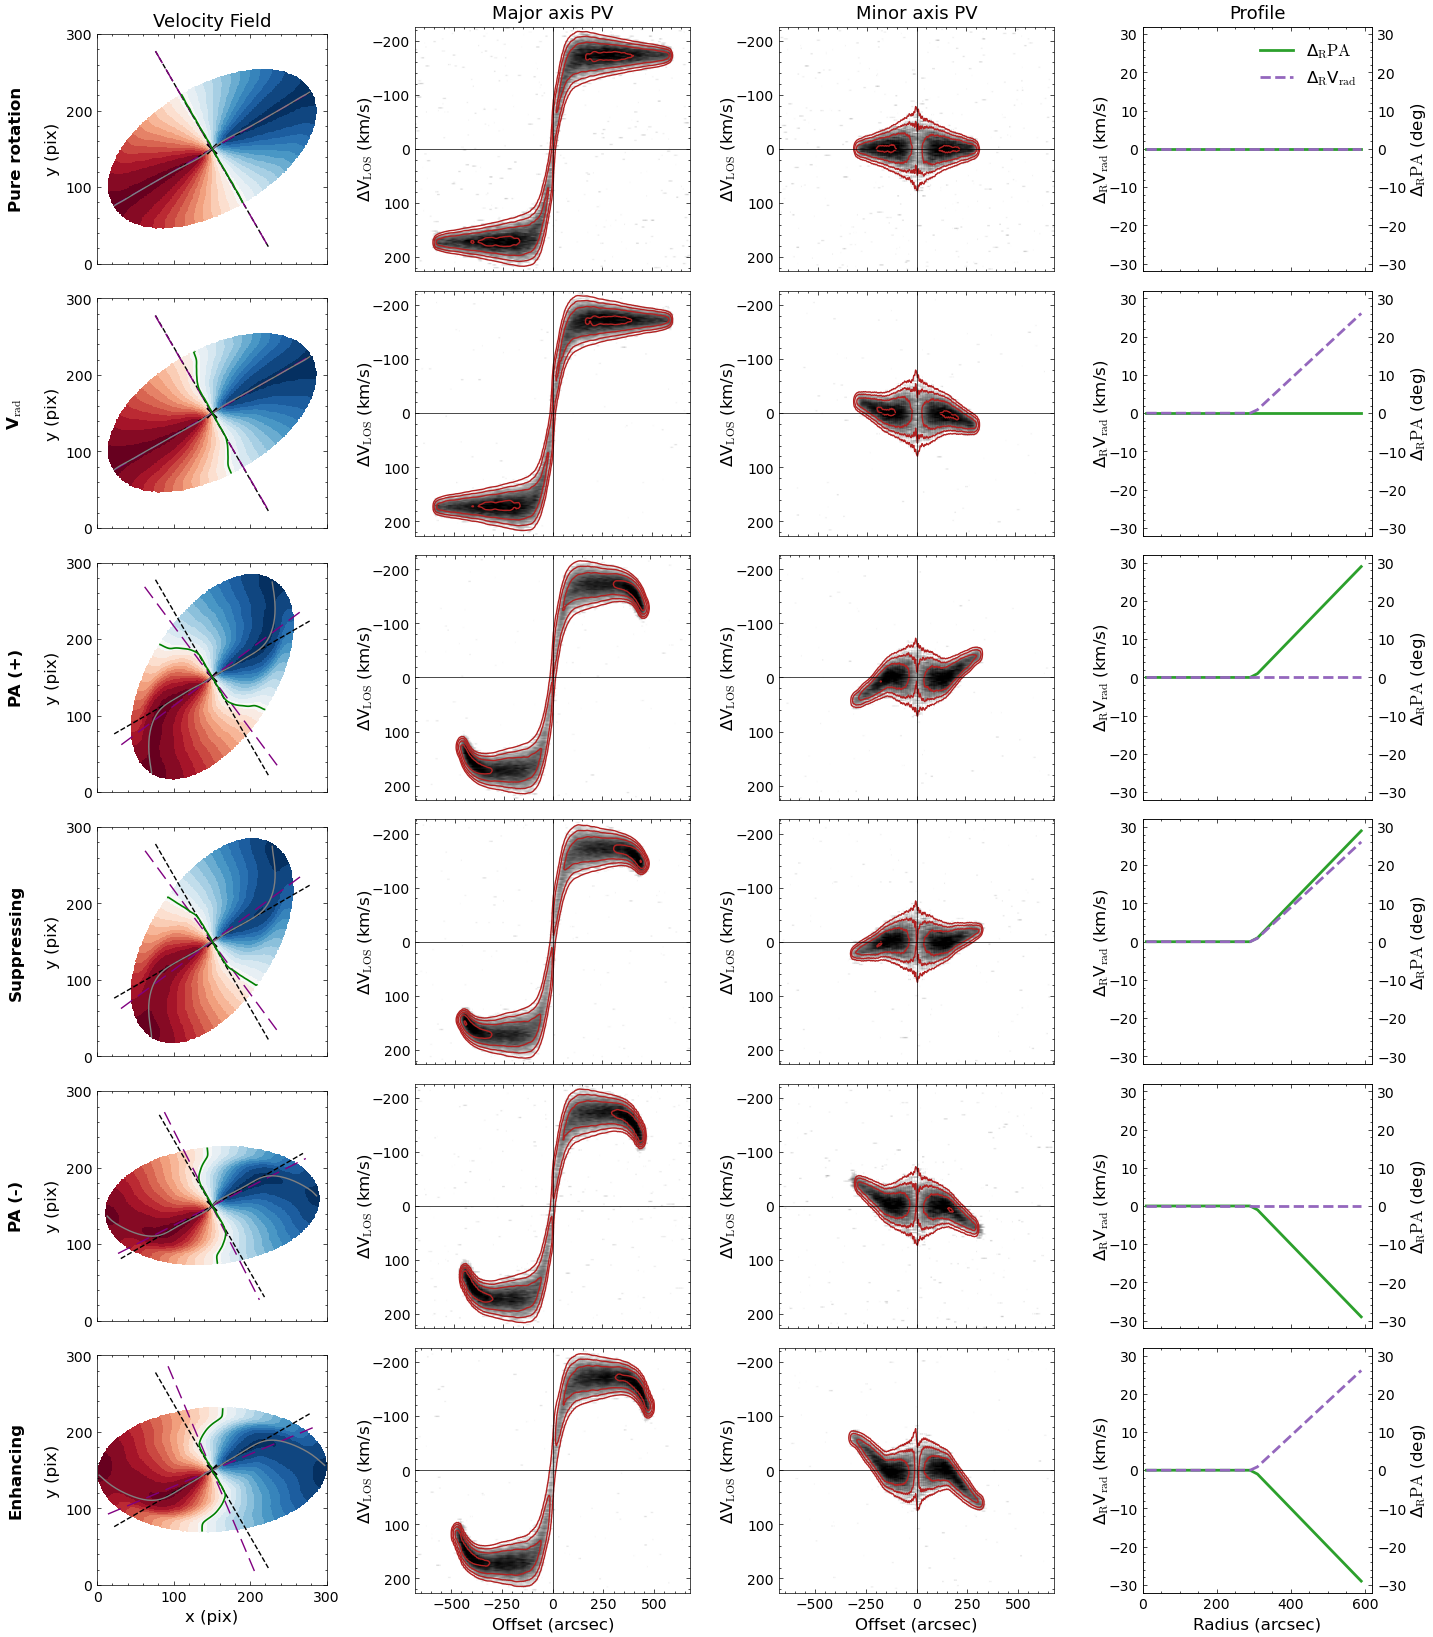

In [1]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import ColorbarBase
from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from copy import copy
import warnings
import glob
from matplotlib.ticker import MultipleLocator

# ================= 基础设置 =================
warnings.filterwarnings("ignore")
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
plt.rc('font', family='sans-serif', serif='Helvetica', size=11)
mpl.rc('xtick', direction='in', top=True)
mpl.rc('ytick', direction='in', right=True)

mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['contour.negative_linestyle'] = 'solid'

params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'}
plt.rcParams.update(params)

# ★★★ 请根据服务器修改此处 ★★★
base_path = '/net/'

# ================= 模型路径配置 =================
models_raw = [
    ("Pure rotation", "dataserver3/data/users/linn/para_Barolo/test_more_model/ring_v200_R50_PAfixed_VR0_INC60/second_step_check_sinw/"),
    (r"$V_{\rm rad}$", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAfixed_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA (+)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VR0_INC60/second_step_check_sinw/"),
    ("Suppressing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk-0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/"),
    ("PA (-)", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VR0_INC60/second_step_check_sinw/SNR10Res10mod_maps_azim.pdf"),
    ("Enhancing", "dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200_R50_PAk0.1_TP300_VRk-0.09_TP300_INC60/second_step_check_sinw/")
]

# 1. 清洗路径 (处理 pdf 结尾, 拼接 base_path)
models_clean = []
for title, path in models_raw:
    if path.endswith('.pdf'):
        path = os.path.dirname(path) + '/'
    if not path.endswith('/'):
        path += '/'
    full_path = os.path.join(base_path, path)
    models_clean.append((title, full_path))

models_ordered = models_clean

# ================= 全局参数 =================
gname = 'SNR10Res10mod'
xmin, xmax = 250, 550
ymin, ymax = 250, 550
zmin, zmax = 10, 190
twostage = 1
cmap_vel = plt.get_cmap('RdBu_r', 25)

# ================= 辅助函数定义 =================

def get_rings_data(outfolder):
    """读取 rings_final2.txt 获取详细几何参数(PA array, Rad array等)用于画线"""
    fname = 'rings_final2.txt' if twostage else 'rings_final1.txt'
    path = os.path.join(outfolder, fname)
    try:
        data = np.genfromtxt(path, usecols=(1, 4, 5, 9, 10, 11), unpack=True)
        rad, inc, pa, xpos, ypos, vsys = data

        return {
            'rad': rad, 'pa': pa,
            'vsys_m': np.nanmean(vsys),
            'xcen_m': np.nanmean(xpos),
            'ycen_m': np.nanmean(ypos),
            'pa_m': np.nanmean(pa),
            'inc_m': np.nanmean(inc)
        }
    except Exception as e:
        print(f"Error reading rings from {path}: {e}")
        return None

def plot_mom1(ax, outfolder, p_data, is_bottom_row, fixed_pa=120.0, model_pa_fixed=None):
    """
    第1列：Data Velocity Field
    - 黑色虚线：固定 PA=120° 的理想无扭曲盘主轴和副轴
    - 紫色虚线：模型平均 PA（或由 model_pa_fixed 指定）定义的主轴和副轴
    - 灰色实线：模型 PA 随半径的变化（若存在）
    """
    if p_data is None:
        ax.text(0.5, 0.5, "No Rings Data", ha='center')
        return None, None

    vsys_m = p_data['vsys_m']
    xcen = p_data['xcen_m'] - xmin
    ycen = p_data['ycen_m'] - ymin
    rad = p_data['rad']
    pa = p_data['pa']
    pa_m = p_data['pa_m']

    fpath = os.path.join(outfolder, 'maps', gname + '_azim_1mom.fits')
    f1 = fits.open(fpath)
    mom1 = f1[0].data[-10+ymin:ymax+10, -10+xmin:xmax+10]
    f1.close()

    data_to_plot = mom1 - vsys_m
    ext = [0, xmax - xmin, 0, ymax - ymin]

    interval = PercentileInterval(100)
    vmin, vmax = interval.get_limits(data_to_plot)
    vabs = max(abs(vmin), abs(vmax))
    norm = mpl.colors.Normalize(vmin=-vabs-10, vmax=vabs+10)

    cmap = copy(cmap_vel)
    cmap.set_bad('w', 1.)

    im = ax.imshow(
        data_to_plot, origin='lower', cmap=cmap, norm=norm,
        aspect='equal', extent=ext, interpolation='nearest'
    )
    ax.plot(xcen, ycen, 'x', color='#000000', markersize=7, mew=1.5)

    rad_pix = rad / 4.0
    r_line = np.linspace(-max(rad_pix), max(rad_pix), 1000)

    # ---- 1. 黑色虚线：固定 PA=120°（理想无扭曲盘） ----
    x_line_fixed = r_line * np.cos(np.radians(fixed_pa - 90)) + xcen
    y_line_fixed = r_line * np.sin(np.radians(fixed_pa - 90)) + ycen
    ax.plot(x_line_fixed, y_line_fixed, '--', color='black', linewidth=1)

    x_line_fixed_min = -r_line * np.cos(np.radians(fixed_pa)) + xcen
    y_line_fixed_min = -r_line * np.sin(np.radians(fixed_pa)) + ycen
    ax.plot(x_line_fixed_min, y_line_fixed_min, '--', color='black', linewidth=1)

    # ---- 2. 紫色虚线：模型平均 PA（或由 model_pa_fixed 指定） ----
    purple_pa = model_pa_fixed if model_pa_fixed is not None else pa_m

    x_line_model = r_line * np.cos(np.radians(purple_pa - 90)) + xcen
    y_line_model = r_line * np.sin(np.radians(purple_pa - 90)) + ycen
    ax.plot(x_line_model, y_line_model,  linestyle=(0, (10, 5)), color='purple', linewidth=1)

    x_line_model_min = -r_line * np.cos(np.radians(purple_pa)) + xcen
    y_line_model_min = -r_line * np.sin(np.radians(purple_pa)) + ycen
    ax.plot(x_line_model_min, y_line_model_min,  linestyle=(0, (10, 5)),  color='purple', linewidth=1)

    if is_bottom_row:
        ax.set_xlabel('x (pix)', fontsize=12)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel('y (pix)', fontsize=12)

    try:
        nr = len(rad_pix)
    except:
        nr = 1

    if nr < 10:
        x_pix = rad_pix * np.cos(np.radians(pa_m - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_m - 90))
        ax.scatter(x_pix + xcen, y_pix + ycen, c='grey', s=12)
        ax.scatter(xcen - x_pix, ycen - y_pix, c='grey', s=12)

    # 灰色实线：模型 PA 随半径变化（若恒定则与紫虚线重合）
    if np.std(pa) < 1e-6:
        pa_use = pa_m
    else:
        pa_use = pa

    if nr > 5 and not np.all(np.diff(pa) == 0):
        x_pix = rad_pix * np.cos(np.radians(pa_use - 90))
        y_pix = rad_pix * np.sin(np.radians(pa_use - 90))
        ax.plot(xcen - x_pix, ycen - y_pix, '-', color='grey', lw=1)
        ax.plot(x_pix + xcen, y_pix + ycen, '-', color='grey', lw=1)

    maskmap = np.copy(mom1)
    maskmap[mom1 == mom1] = 1
    ax.contour(
        data_to_plot * maskmap, levels=[0], colors='green',
        origin='lower', extent=ext, linewidths=1.2
    )

    return im, norm

def plot_pv_hybrid(ax, outfolder, pv_type, p_data, is_left_col, is_bottom):
    """
    第2、3列：PV Diagrams
    背景：Data grey scale
    Contour：Model red contour
    """
    vsys_m = p_data['vsys_m']

    suffix_data = '_pv_a.fits' if pv_type == 'major' else '_pv_b.fits'
    f_data_path = os.path.join(outfolder, 'pvs', gname + suffix_data)

    if not os.path.exists(f_data_path):
        ax.text(0.5, 0.5, "Data PV Missing", ha='center')
        return

    f = fits.open(f_data_path)
    head = f[0].header

    crpix = head['CRPIX1']
    cdelt = head['CDELT1']
    crval = head['CRVAL1']
    naxis1 = head['NAXIS1']

    xminpv = max(0, np.floor(crpix - 1 - 150))
    xmaxpv = min(naxis1 - 1, np.ceil(crpix - 1 + 150))

    xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
    xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600

    zmin_wcs, zmax_wcs = 262.75, -189.75
    ext = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]

    data_crop = f[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
    f.close()

    cont = 0.000598286
    interval = PercentileInterval(99.5)
    vmax_norm = interval.get_limits(data_crop)[1]

    if np.isnan(vmax_norm):
        vmax_norm = cont * 10

    norm = ImageNormalize(vmin=cont, vmax=vmax_norm, stretch=PowerStretch(0.5))

    ax.imshow(
        data_crop, origin='lower', cmap=mpl.cm.Greys, norm=norm,
        extent=ext, aspect='auto'
    )

    suffix_mod = f'pv_{"a" if pv_type == "major" else "b"}_azim.fits'
    mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))

    if not mod_files:
        suffix_mod = f'pv_{"a" if pv_type == "major" else "b"}_local.fits'
        mod_files = glob.glob(os.path.join(outfolder, 'pvs', '*' + suffix_mod))

    if mod_files:
        f_mod = fits.open(mod_files[0])
        mod_crop = f_mod[0].data[zmin:zmax+1, int(xminpv):int(xmaxpv)+1]
        v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont
        ax.contour(
            mod_crop, v_levels, origin='lower',
            linewidths=1, colors='#B22222', extent=ext
        )
        f_mod.close()

    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)

    ax.set_ylabel(r'$\Delta V_{\rm LOS}$ (km/s)', fontsize=12, labelpad=-2)

    if is_bottom:
        ax.set_xlabel('Offset (arcsec)', fontsize=12)
    else:
        ax.set_xticklabels([])

def get_initial_profile_path(barolo_path):
    """
    将 Barolo 输出路径转换为 Initial Parameter 的 txt 路径
    """
    p = os.path.normpath(barolo_path)
    if p.endswith('.pdf'):
        p = os.path.dirname(p)
    if os.path.basename(p) == 'second_step_check_sinw':
        p = os.path.dirname(p)
    new_path_base = p.replace('para_Barolo', 'para_initial')
    txt_path = new_path_base + ".txt"
    return txt_path

def plot_real_profile(ax, barolo_path, row_idx, is_bottom_row):
    """
    读取对应的 initial txt 文件，并绘制 PA 和 VRAD profile
    """
    txt_path = get_initial_profile_path(barolo_path)

    if not os.path.exists(txt_path):
        ax.text(0.5, 0.5, "Txt Not Found", ha='center', fontsize=8)
        print(f"Missing: {txt_path}")
        return

    try:
        try:
            data = np.genfromtxt(txt_path, names=True, encoding=None)
            colnames = [n.upper() for n in data.dtype.names]

            col_rad = next(n for n in colnames if 'RAD' in n)
            col_pa = next(n for n in colnames if 'P.A' in n or 'PA' in n)
            col_vrad = next(n for n in colnames if 'VRAD' in n)

            rad = data[data.dtype.names[colnames.index(col_rad)]]
            pa = data[data.dtype.names[colnames.index(col_pa)]]
            vrad = data[data.dtype.names[colnames.index(col_vrad)]]

        except:
            data_arr = np.genfromtxt(txt_path)
            rad = data_arr[:, 0]
            pa = data_arr[:, 1]
            vrad = data_arr[:, 2]

        color_pa = '#2ca02c'
        color_vr = '#9467bd'

        pa = pa - 120

        ax.plot(rad, pa, '-', color=color_pa, lw=2, label=r'$\Delta_{\rm R}{\rm PA}$')
        ax.plot(rad, vrad, '--', color=color_vr, lw=2, label=r'$\Delta_{\rm R}V_{\rm rad}$')

        ax.set_xlim(left=0, right=np.max(rad) * 1.05)
        ax.set_ylim(-32, 32)

        if is_bottom_row:
            ax.set_xlabel('Radius (arcsec)', fontsize=12)
        else:
            ax.tick_params(labelbottom=False)

        ax.set_ylabel(r'$\Delta_{\rm R}V_{\rm rad}$ (km/s)', fontsize=12, labelpad=-2)

        ax2 = ax.twinx()
        ax2.set_ylim(-32, 32)
        ax2.set_ylabel(r'$\Delta_{\rm R}{\rm PA}$ (deg)', fontsize=12, labelpad=2)
        ax2.tick_params(labelsize=10)

        if row_idx == 0:
            ax.legend(loc='upper right', fontsize=12, frameon=False)

    except Exception as e:
        ax.text(0.5, 0.5, "Read Error", ha='center', fontsize=8)
        print(f"Error reading {txt_path}: {e}")

# ================= 主程序执行 =================

fig = plt.figure(figsize=(15, 18))
gs = gridspec.GridSpec(6, 4, width_ratios=[1, 1.2, 1.2, 1], wspace=0.35, hspace=0.08)
rows = 6

global_im, global_norm = None, None

for i in range(rows):
    title, path = models_ordered[i]
    is_bottom = (i == rows - 1)
    print(f"Plotting Row {i+1}: {title}...")

    p_data = get_rings_data(path)
    if p_data is None:
        print(f"Skipping row {i} (no data)")
        continue

    # --- 1. Data Velocity Field ---
    ax0 = fig.add_subplot(gs[i, 0])
    # 第一行紫色虚线也固定为120°（纯旋转模型）
    if i == 0:
        im, norm = plot_mom1(ax0, path, p_data, is_bottom_row=is_bottom,
                             fixed_pa=120.0, model_pa_fixed=120.0)
    else:
        im, norm = plot_mom1(ax0, path, p_data, is_bottom_row=is_bottom,
                             fixed_pa=120.0)
    if i == 0:
        global_im, global_norm = im, norm
        ax0.set_title("Velocity Field")

    ax0.text(-0.32, 0.5, title, transform=ax0.transAxes,
             va='center', ha='right', fontsize=12, fontweight='bold', rotation=90)
    ax0.xaxis.set_major_locator(MultipleLocator(100))
    ax0.yaxis.set_major_locator(MultipleLocator(100))

    # --- 2. PV Major (Data=Grey, Model=Red) ---
    ax1 = fig.add_subplot(gs[i, 1])
    plot_pv_hybrid(ax1, path, 'major', p_data, is_left_col=True, is_bottom=is_bottom)
    if i == 0:
        ax1.set_title("Major axis PV")

    # --- 3. PV Minor (Data=Grey, Model=Red) ---
    ax2 = fig.add_subplot(gs[i, 2])
    plot_pv_hybrid(ax2, path, 'minor', p_data, is_left_col=False, is_bottom=is_bottom)
    if i == 0:
        ax2.set_title("Minor axis PV")

    # --- 4. Profile ---
    ax3 = fig.add_subplot(gs[i, 3])
    plot_real_profile(ax3, path, i, is_bottom)
    if i == 0:
        ax3.set_title("Profile")

# --- 添加 Colorbar (Velocity Field) ---
# if global_im:
#     pos_last = fig.add_subplot(gs[rows-1, 0]).get_position()
#     cax = fig.add_axes([pos_last.x0, pos_last.y0 - 0.04, pos_last.width, 0.01])
#     cb = ColorbarBase(cax, orientation='horizontal', cmap=cmap_vel, norm=global_norm)
#     cb.set_label(r'$\Delta V_{LOS}$ (km/s)', fontsize=9)

output_file = 'Final_Kinematic_Comparison_6x4_test.pdf'
plt.subplots_adjust(left=0.1, bottom=0.08, right=0.95, top=0.95)
fig.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"Finished. Saved to {output_file}")

In [ ]:
/Users/users/linn/DATASERVER3/para_Barolo/test_more_model/figureforpaper/figure1-velocityfield_enhanc_supressing.ipynb